# Libraries and functions

In [1]:
from pathlib import Path
import json
import itertools
import math

import torch
import numpy as np
import matplotlib.pyplot as plt

# at the top of the notebook/script
from global_chanju.paulplot.rc_setter import set_rc, get_rc
from global_chanju.paulplot.styles import nice_style

set_rc(scale=1.0)

plt.rcParams.update({
    "text.usetex": False,          # keep False if LaTeX is not installed
    "font.family": "serif",
    "mathtext.fontset": "cm",      # Computer Modern math
    "axes.formatter.use_mathtext": True,
})

/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _as_list(x):
    return x if isinstance(x, list) else [x]


def _cartesian_product_like_driver(grid):
    keys = sorted(grid.keys())
    values_lists = [_as_list(grid[k]) for k in keys]

    combos = []
    for values in itertools.product(*values_lists):
        combos.append({k: v for k, v in zip(keys, values)})

    return combos


def _get_times_and_blocks(payload):
    if "times" in payload and "by_time" in payload:
        return payload["times"], payload["by_time"]

    if "epochs" in payload and "by_epoch" in payload:
        return payload["epochs"], payload["by_epoch"]

    raise ValueError("Unknown SVD payload format.")


def _build_combos_with_coupled_grid_like_driver(cfg):
    """
    Reproduce the same order used in experiment_age_phase_diagram.py:

        base_combos = cartesian_product(grid)
        for base in base_combos:
            for coupled in coupled_grid:
                merged = base + coupled

    In the usual case, base_combos has length 1, so combo_index == q.
    """
    grid = cfg.get("grid", {})
    coupled_grid = cfg.get("coupled_grid", None)

    if not grid:
        raise ValueError("Config must contain a non-empty 'grid' dictionary.")

    if not isinstance(coupled_grid, list) or len(coupled_grid) == 0:
        raise ValueError(
            "list_instead_of_grid=True requires a non-empty 'coupled_grid' list."
        )

    for q, point in enumerate(coupled_grid):
        if not isinstance(point, dict):
            raise ValueError(f"coupled_grid[{q}] must be a dictionary.")
        if "lr" not in point or "inv_sigma_w" not in point:
            raise ValueError(
                f"coupled_grid[{q}] must contain both 'lr' and 'inv_sigma_w'."
            )

    coupled_keys = set()
    for point in coupled_grid:
        coupled_keys.update(point.keys())

    overlap = set(grid.keys()).intersection(coupled_keys)
    if overlap:
        raise ValueError(
            "A parameter cannot appear both in grid and coupled_grid. "
            f"Overlapping keys: {sorted(overlap)}"
        )

    base_combos = _cartesian_product_like_driver(grid)

    combos = []
    records = []

    for base_index, base_combo in enumerate(base_combos):
        for q, coupled_point in enumerate(coupled_grid):
            combo = dict(base_combo)
            combo.update(dict(coupled_point))

            combo_index = len(combos)
            combos.append(combo)

            records.append(
                {
                    "q": q,
                    "base_index": base_index,
                    "combo_index": combo_index,
                    "combo": combo,
                }
            )

    return combos, records


def _find_first_available_seed_svd_file(combo_dir, svd_filename):
    """
    Return only one SVD file.

    If the combo folder contains several seed folders, use the first seed folder
    that contains svd_filename. This avoids concatenating histograms across seeds.

    Expected structure:
        combo_0000_hash/
            seed_0001_hash/svd_diagnostics.pt
            seed_0002_hash/svd_diagnostics.pt
            ...

    Returns
    -------
    svd_path, seed_dir
    """
    combo_dir = Path(combo_dir)

    seed_dirs = sorted(
        p for p in combo_dir.glob("seed_*")
        if p.is_dir()
    )

    if len(seed_dirs) > 0:
        for seed_dir in seed_dirs:
            candidates = sorted(seed_dir.rglob(svd_filename))
            if len(candidates) > 0:
                return candidates[0], seed_dir

        return None, None

    # Fallback for old layouts without seed_* folders.
    candidates = sorted(combo_dir.rglob(svd_filename))
    if len(candidates) > 0:
        return candidates[0], candidates[0].parent

    return None, None


def _load_single_svd_file_into_entry(
    *,
    entry,
    svd_path,
    value_keys,
):
    payload = torch.load(svd_path, map_location="cpu")
    times, blocks = _get_times_and_blocks(payload)

    for t in times:
        t_int = int(t)
        t_key = str(t_int)
        if t_key not in blocks:
            t_key = str(t)

        block = blocks[t_key]
        layer_order = block.get("layer_order", list(block["layers"].keys()))

        if entry["layer_order"] is None:
            entry["layer_order"] = list(layer_order)

        if t_int not in entry["by_time"]:
            entry["by_time"][t_int] = {}

        for layer_name in layer_order:
            if layer_name not in entry["by_time"][t_int]:
                entry["by_time"][t_int][layer_name] = {
                    key: [] for key in value_keys
                }

            layer_payload = block["layers"][layer_name]

            for key in value_keys:
                if key in layer_payload:
                    vals = np.asarray(layer_payload[key], dtype=np.float64)
                    entry["by_time"][t_int][layer_name][key].append(vals)

    # Convert list-of-arrays to one array.
    for t in entry["by_time"]:
        for layer_name in entry["by_time"][t]:
            for key in value_keys:
                arrays = entry["by_time"][t][layer_name][key]
                if len(arrays) > 0:
                    entry["by_time"][t][layer_name][key] = np.concatenate(arrays)
                else:
                    entry["by_time"][t][layer_name][key] = np.array([], dtype=np.float64)


def load_all_svd_once(
    results_dir,
    config_path,
    *,
    svd_filename="svd_diagnostics.pt",
    value_keys=("gram_eigenvalues", "singular_values"),
    list_instead_of_grid=False,
):
    """
    Load SVD diagnostics once.

    Old mode
    --------
    list_instead_of_grid=False

    Config has:
        grid["lr"]
        grid["inv_sigma_w"]

    Store key:
        store["data"][(a,b)]

    where:
        a = lr index
        b = inv_sigma_w index

    New mode
    --------
    list_instead_of_grid=True

    Config has:
        grid = fixed hyperparameters
        coupled_grid = [
            {"lr": ..., "inv_sigma_w": ...},
            {"lr": ..., "inv_sigma_w": ...},
            ...
        ]

    Store key:
        store["data"][q]

    where:
        q = index inside coupled_grid.

    Seed behavior
    -------------
    If more than one seed exists inside a combo folder, this function loads only
    the first seed folder available. It does not concatenate across seeds.
    """
    results_dir = Path(results_dir)
    config_path = Path(config_path)

    cfg = json.loads(config_path.read_text())
    grid = cfg["grid"]

    store = {
        "results_dir": results_dir,
        "config_path": config_path,
        "list_instead_of_grid": bool(list_instead_of_grid),
        "data": {},
        "combos": None,
        "lr_values": None,
        "inv_sigma_w_values": None,
        "coupled_grid": cfg.get("coupled_grid", None),
        "key_meaning": None,
    }

    # ============================================================
    # MODE 1: old Cartesian grid
    # ============================================================
    if not list_instead_of_grid:
        if "lr" not in grid or "inv_sigma_w" not in grid:
            raise ValueError(
                "list_instead_of_grid=False requires grid['lr'] and grid['inv_sigma_w']. "
                "For coupled_grid configs, use list_instead_of_grid=True."
            )

        lr_values = _as_list(grid["lr"])
        inv_sigma_w_values = _as_list(grid["inv_sigma_w"])
        combos = _cartesian_product_like_driver(grid)

        store["combos"] = combos
        store["lr_values"] = lr_values
        store["inv_sigma_w_values"] = inv_sigma_w_values
        store["key_meaning"] = "(a,b) = (lr_index, inv_sigma_w_index)"

        for a, lr in enumerate(lr_values):
            for b, inv_sigma_w in enumerate(inv_sigma_w_values):
                matching_combo_indices = []

                for combo_index, combo in enumerate(combos):
                    if (
                        np.isclose(float(combo.get("lr")), float(lr), rtol=1e-14, atol=0.0)
                        and np.isclose(
                            float(combo.get("inv_sigma_w")),
                            float(inv_sigma_w),
                            rtol=1e-14,
                            atol=0.0,
                        )
                    ):
                        matching_combo_indices.append(combo_index)

                if len(matching_combo_indices) == 0:
                    continue

                if len(matching_combo_indices) > 1:
                    print(
                        f"[WARN] More than one combo matches (a,b)=({a},{b}). "
                        f"I will use the first one: {matching_combo_indices[0]}"
                    )

                combo_index = matching_combo_indices[0]
                combo = combos[combo_index]

                combo_dirs = sorted(results_dir.glob(f"combo_{combo_index:04d}_*"))
                if len(combo_dirs) == 0:
                    print(
                        f"[WARN] Missing folder for combo_index={combo_index}, "
                        f"(a,b)=({a},{b})"
                    )
                    continue

                combo_dir = combo_dirs[0]
                svd_path, seed_dir = _find_first_available_seed_svd_file(
                    combo_dir,
                    svd_filename,
                )

                if svd_path is None:
                    print(
                        f"[WARN] No {svd_filename} found for combo_index={combo_index}, "
                        f"(a,b)=({a},{b})"
                    )
                    continue

                entry = {
                    "a": a,
                    "b": b,
                    "q": None,
                    "combo_index": combo_index,
                    "combo": combo,
                    "combo_dir": combo_dir,
                    "seed_dir_used": seed_dir,
                    "svd_file_used": svd_path,
                    "svd_files": [svd_path],
                    "by_time": {},
                    "layer_order": None,
                }

                _load_single_svd_file_into_entry(
                    entry=entry,
                    svd_path=svd_path,
                    value_keys=value_keys,
                )

                store["data"][(a, b)] = entry

        print(f"[DONE] loaded {len(store['data'])} available (a,b) combos into memory.")
        print("[INFO] mode = grid")
        print("[INFO] key meaning:", store["key_meaning"])
        return store

    # ============================================================
    # MODE 2: coupled_grid list
    # ============================================================
    combos, records = _build_combos_with_coupled_grid_like_driver(cfg)

    store["combos"] = combos
    store["lr_values"] = [point["lr"] for point in cfg["coupled_grid"]]
    store["inv_sigma_w_values"] = [point["inv_sigma_w"] for point in cfg["coupled_grid"]]
    store["key_meaning"] = "q = index inside coupled_grid"

    for record in records:
        q = int(record["q"])
        base_index = int(record["base_index"])
        combo_index = int(record["combo_index"])
        combo = record["combo"]

        # If the base grid has more than one combo, the same q appears several times.
        # In that case we use a tuple key to avoid collisions.
        # In your usual case base_index=0, so the key is simply q.
        if len(_cartesian_product_like_driver(grid)) == 1:
            data_key = q
        else:
            data_key = (q, base_index)

        combo_dirs = sorted(results_dir.glob(f"combo_{combo_index:04d}_*"))
        if len(combo_dirs) == 0:
            print(
                f"[WARN] Missing folder for combo_index={combo_index}, "
                f"q={q}, base_index={base_index}, combo={combo}"
            )
            continue

        combo_dir = combo_dirs[0]
        svd_path, seed_dir = _find_first_available_seed_svd_file(
            combo_dir,
            svd_filename,
        )

        if svd_path is None:
            print(
                f"[WARN] No {svd_filename} found for combo_index={combo_index}, "
                f"q={q}, base_index={base_index}, combo={combo}"
            )
            continue

        entry = {
            "a": None,
            "b": None,
            "q": q,
            "base_index": base_index,
            "combo_index": combo_index,
            "combo": combo,
            "combo_dir": combo_dir,
            "seed_dir_used": seed_dir,
            "svd_file_used": svd_path,
            "svd_files": [svd_path],
            "by_time": {},
            "layer_order": None,
        }

        _load_single_svd_file_into_entry(
            entry=entry,
            svd_path=svd_path,
            value_keys=value_keys,
        )

        store["data"][data_key] = entry

    print(f"[DONE] loaded {len(store['data'])} available q combos into memory.")
    print("[INFO] mode = list/coupled_grid")
    print("[INFO] key meaning:", store["key_meaning"])
    print("[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...")
    return store

In [3]:
def _normalise_layer_name_for_overlap(layer_name):
    layer_name = str(layer_name)
    if layer_name.endswith(".weight"):
        layer_name = layer_name[: -len(".weight")]
    return layer_name


def _get_overlap_A_text_for_panel(
    q_a,
    *,
    lr,
    inv_sigma_w,
    epoch,
    layer_name,
    value_field="A_mean",
    std_field="A_std",
    rtol=1e-12,
    atol=1e-15,
    fmt=".3f",
):
    if q_a is None:
        return None

    required = {"lr", "inv_sigma_w", "epoch", "layer_name", value_field, std_field}
    available = set(q_a.dtype.names or [])
    missing = required - available
    if missing:
        raise ValueError(
            f"q_a is missing required fields: {sorted(missing)}. "
            f"Available fields are: {sorted(available)}"
        )

    target_layer = _normalise_layer_name_for_overlap(layer_name)
    q_layers = np.array(
        [_normalise_layer_name_for_overlap(x) for x in q_a["layer_name"]],
        dtype=object,
    )

    mask = (
        np.isclose(q_a["lr"].astype(float), float(lr), rtol=rtol, atol=atol)
        & np.isclose(q_a["inv_sigma_w"].astype(float), float(inv_sigma_w), rtol=rtol, atol=atol)
        & (q_a["epoch"].astype(int) == int(epoch))
        & (q_layers == target_layer)
    )

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None

    row = q_a[idx[0]]

    val = float(row[value_field])
    std = float(row[std_field])

    if not np.isfinite(val):
        return None

    if np.isfinite(std):
        return rf"$q = {val:{fmt}} \pm {std:{fmt}}$"
    
    return rf"$q = {val:{fmt}}$"


def plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    *,
    a=None,
    b=None,
    list_instead_of_grid=False,
    list_number=None,
    layers=None,
    validation_times=None,
    value_key="gram_eigenvalues",
    bins=40,
    log_x=True,
    density=True,
    shared_bins="layer",
    figsize_per_panel=(3.6, 2.7),
    q_a=None,
    overlap_value_field="A_mean",
    overlap_std_field="A_std",
    overlap_fmt=".3f",
    overlap_rtol=1e-12,
    overlap_atol=1e-15,
    mark_top_k=5,
    mark_top_k_color="red",
    mark_top_k_size=45,
):
    """
    SAME FUNCTION NAME, two possible modes.

    OLD GRID MODE
    -------------
    list_instead_of_grid=False

    Use:
        plot_svd_histograms_layers_by_time_from_store(
            svd_store,
            a=4,
            b=4,
            layers=["layers.0"],
            ...
        )

    The function uses:
        svd_store["data"][(a,b)]


    NEW COUPLED-GRID / LIST MODE
    ----------------------------
    list_instead_of_grid=True

    Use:
        plot_svd_histograms_layers_by_time_from_store(
            svd_store,
            list_instead_of_grid=True,
            list_number=4,
            layers=["layers.0"],
            ...
        )

    The function uses:
        svd_store["data"][list_number]

    So list_number=4 means:
        cfg["coupled_grid"][4]
    """

    # ------------------------------------------------------------
    # Select the correct key without changing the function name.
    # ------------------------------------------------------------
    if list_instead_of_grid:
        if list_number is None:
            raise ValueError(
                "You set list_instead_of_grid=True, so you must pass list_number=0,1,2,..."
            )

        key = int(list_number)

        # Standard case from the loader I gave you:
        # store["data"][q]
        if key not in svd_store["data"]:
            # Fallback if the loader used (q, base_index), typically (q,0).
            fallback_key = (key, 0)
            if fallback_key in svd_store["data"]:
                key = fallback_key
            else:
                available = list(svd_store["data"].keys())
                raise KeyError(
                    f"No loaded data for list_number={list_number}. "
                    f"Available keys are: {available}"
                )

        mode_label = f"list_number={list_number}"

    else:
        if a is None or b is None:
            raise ValueError(
                "You set list_instead_of_grid=False, so you must pass both a=... and b=..."
            )

        key = (int(a), int(b))

        if key not in svd_store["data"]:
            available = list(svd_store["data"].keys())
            raise KeyError(
                f"No loaded data for combo (a,b)=({a},{b}). "
                f"Available keys are: {available}"
            )

        mode_label = f"combo ({int(a)},{int(b)})"

    entry = svd_store["data"][key]
    combo = entry["combo"]
    by_time = entry["by_time"]

    lr = float(combo["lr"])
    inv_sigma_w = float(combo["inv_sigma_w"])

    available_times = sorted(int(t) for t in by_time.keys())

    if validation_times is None:
        validation_times = available_times
    else:
        validation_times = [int(t) for t in validation_times]

    if len(validation_times) == 0:
        raise ValueError("validation_times cannot be empty.")

    for t in validation_times:
        if t not in by_time:
            raise KeyError(
                f"Validation time {t} not found for {mode_label}. "
                f"Available times: {available_times}"
            )

    if layers is None:
        first_t = validation_times[0]
        layers = list(by_time[first_t].keys())
    else:
        layers = list(layers)

    if len(layers) == 0:
        raise ValueError("layers cannot be empty.")

    n_rows = len(layers)
    n_cols = len(validation_times)

    values = {}

    for layer in layers:
        values[layer] = {}

        for t in validation_times:
            if layer not in by_time[t]:
                available_layers = list(by_time[t].keys())
                raise KeyError(
                    f"Layer '{layer}' not found for {mode_label} at time {t}. "
                    f"Available layers: {available_layers}"
                )

            if value_key not in by_time[t][layer]:
                available_keys = list(by_time[t][layer].keys())
                raise KeyError(
                    f"value_key='{value_key}' not found for layer '{layer}' "
                    f"at {mode_label}, time={t}. "
                    f"Available keys: {available_keys}"
                )

            vals = np.asarray(by_time[t][layer][value_key], dtype=np.float64)
            vals = vals[np.isfinite(vals)]

            if log_x:
                vals = vals[vals > 0]

            values[layer][t] = vals

    def make_bins(arr):
        arr = np.asarray(arr, dtype=np.float64)
        arr = arr[np.isfinite(arr)]

        if len(arr) == 0:
            return None

        if log_x:
            arr = arr[arr > 0]
            if len(arr) == 0:
                return None

            vmin = arr.min()
            vmax = arr.max()

            if vmin == vmax:
                vmin *= 0.9
                vmax *= 1.1

            return np.logspace(np.log10(vmin), np.log10(vmax), bins)

        vmin = arr.min()
        vmax = arr.max()

        if vmin == vmax:
            vmin -= 0.5
            vmax += 0.5

        return np.linspace(vmin, vmax, bins)

    global_bins = None
    if shared_bins == "global":
        all_vals = []
        for layer in layers:
            for t in validation_times:
                if len(values[layer][t]) > 0:
                    all_vals.append(values[layer][t])

        global_bins = make_bins(np.concatenate(all_vals)) if len(all_vals) > 0 else None

    layer_bins = {}
    if shared_bins == "layer":
        for layer in layers:
            all_vals = [
                values[layer][t]
                for t in validation_times
                if len(values[layer][t]) > 0
            ]
            layer_bins[layer] = make_bins(np.concatenate(all_vals)) if len(all_vals) > 0 else None

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )

    for row, layer in enumerate(layers):
        for col, t in enumerate(validation_times):
            ax = axes[row, col]
            vals = values[layer][t]

            if shared_bins == "global":
                hist_bins = global_bins
            elif shared_bins == "layer":
                hist_bins = layer_bins[layer]
            elif shared_bins == "panel":
                hist_bins = make_bins(vals)
            else:
                raise ValueError("shared_bins must be one of: 'layer', 'global', 'panel'.")

            if hist_bins is None or len(vals) == 0:
                ax.text(
                    0.5,
                    0.5,
                    "no values",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
            else:
                hist_counts, hist_edges, _ = ax.hist(vals, bins=hist_bins, density=density)
            
                # Red crosses on the largest singular/eigen values.
                # For singular values this marks the top singular values.
                if mark_top_k is not None and int(mark_top_k) > 0:
                    finite_vals = vals[np.isfinite(vals)]
                    if log_x:
                        finite_vals = finite_vals[finite_vals > 0]
            
                    if len(finite_vals) > 0:
                        top_vals = np.sort(finite_vals)[-int(mark_top_k):]
            
                        x_marks = []
                        y_marks = []
            
                        for x_val in top_vals:
                            bin_idx = np.searchsorted(hist_edges, x_val, side="right") - 1
                            bin_idx = max(0, min(bin_idx, len(hist_counts) - 1))
            
                            y_val = hist_counts[bin_idx]
            
                            # If the bin height is zero for numerical/binning reasons,
                            # put the cross slightly above the axis.
                            if not np.isfinite(y_val) or y_val <= 0:
                                positive_counts = hist_counts[np.isfinite(hist_counts) & (hist_counts > 0)]
                                if len(positive_counts) > 0:
                                    y_val = 0.05 * np.max(positive_counts)
                                else:
                                    y_val = 1.0
            
                            x_marks.append(x_val)
                            y_marks.append(y_val)
            
                        ax.scatter(
                            x_marks,
                            y_marks,
                            marker="x",
                            s=mark_top_k_size,
                            color=mark_top_k_color,
                            linewidths=1.5,
                            zorder=10,
                        )

            if log_x:
                ax.set_xscale("log")

            overlap_text = _get_overlap_A_text_for_panel(
                q_a,
                lr=lr,
                inv_sigma_w=inv_sigma_w,
                epoch=t,
                layer_name=layer,
                value_field=overlap_value_field,
                std_field=overlap_std_field,
                rtol=overlap_rtol,
                atol=overlap_atol,
                fmt=overlap_fmt,
            )

            title_lines = [
                f"{layer}",
                f"epoch = {t}",
            ]

            if overlap_text is not None:
                title_lines.append(overlap_text)

            ax.set_title("\n".join(title_lines), fontsize=10)

            if col == 0:
                ax.set_ylabel("density" if density else "count")

            if row == n_rows - 1:
                if value_key == "gram_eigenvalues":
                    ax.set_xlabel(r"eigenvalues of $W W^T$")
                else:
                    ax.set_xlabel("singular values")

    fig.suptitle(
        f"{mode_label} | lr={lr:g} | inv_sigma_w={inv_sigma_w:g} | quantity={value_key}",
        y=1.02,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, axes

In [4]:
# ============================================================
# Compatibility + missing helpers for top right singular images
# Paste this AFTER the qC/subspace-overlap block
# and BEFORE plot_top_right_vectors_and_dataset_average
# ============================================================

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Aliases: your previous code defines these with "_"
# ------------------------------------------------------------

# resolve_combo_index_from_config = _resolve_combo_index_from_config
# find_combo_dir = _find_combo_dir
# resolve_weight_key = _resolve_weight_key
# weight_tensor_to_matrix = _weight_tensor_to_matrix
# normalise_layer_name = _normalise_layer_name
# extract_state_dict_from_checkpoint = _extract_state_dict


def find_seed_checkpoint_file(
    combo_dir,
    *,
    seed=None,
    seed_index=0,
    checkpoint_filename="weight_checkpoints.pt",
):
    """
    Return one seed entry from a combo folder.

    If seed is provided, select that exact seed.
    Otherwise select by seed_index after sorting by seed.
    """
    entries = _find_seed_checkpoint_files(
        combo_dir,
        checkpoint_filename=checkpoint_filename,
    )

    if seed is not None:
        seed = int(seed)
        matches = [e for e in entries if int(e["seed"]) == seed]

        if len(matches) == 0:
            available = [int(e["seed"]) for e in entries]
            raise ValueError(
                f"Seed {seed} not found in {combo_dir}. "
                f"Available seeds: {available}"
            )

        return matches[0]

    seed_index = int(seed_index)

    if seed_index < 0 or seed_index >= len(entries):
        raise IndexError(
            f"seed_index={seed_index} out of range. "
            f"Available indices: 0,...,{len(entries)-1}"
        )

    return entries[seed_index]


# ------------------------------------------------------------
# 2. Resolve dataset path from config
# ------------------------------------------------------------

def _resolve_existing_path_from_config(config_path, path_value):
    """
    Resolve absolute or relative paths appearing in config files.

    It tries:
      1. the path as written;
      2. relative to config_path.parent;
      3. relative to parents of config_path.
    """
    config_path = Path(config_path).expanduser().resolve()
    p = Path(path_value).expanduser()

    if p.is_absolute():
        return p

    candidates = [config_path.parent / p]
    candidates += [parent / p for parent in config_path.parents]

    for c in candidates:
        if c.exists():
            return c.resolve()

    # fallback: return relative to current working directory
    return p.resolve()


def resolve_dataset_root_from_config(config_path):
    """
    Prefer the processed npz if present, because this is usually
    the exact representation used by training.
    Otherwise return dataset.root.
    """
    cfg = _load_json(config_path)
    ds = cfg.get("dataset", {})

    for key in ["processed_path", "processed_npz", "data_path"]:
        if key in ds and ds[key] is not None:
            p = _resolve_existing_path_from_config(config_path, ds[key])
            if p.exists():
                return p

    for key in ["root", "dataset_root"]:
        if key in ds and ds[key] is not None:
            p = _resolve_existing_path_from_config(config_path, ds[key])
            if p.exists():
                return p

    raise KeyError(
        "Could not infer dataset path from config. Expected one of: "
        "dataset.processed_path, dataset.processed_npz, dataset.data_path, "
        "dataset.root, dataset.dataset_root."
    )


# ------------------------------------------------------------
# 3. Load images and compute average image
# ------------------------------------------------------------

def _pick_image_array_from_npz(npz):
    """
    Try to find the image/input array inside a processed dataset npz.
    """
    preferred_keys = [
        "X_train",
        "x_train",
        "train_x",
        "train_images",
        "images_train",
        "X",
        "x",
        "images",
        "inputs",
    ]

    for key in preferred_keys:
        if key in npz:
            return npz[key], key

    # fallback: first array with at least 2 dimensions and enough entries
    for key in npz.files:
        arr = npz[key]
        if isinstance(arr, np.ndarray) and arr.ndim >= 2 and arr.shape[0] > 1:
            return arr, key

    raise KeyError(
        f"Could not find image/input array in npz. Available keys: {npz.files}"
    )


def _to_nchw_images(X, *, image_size=64):
    """
    Convert common image formats to [N, C, H, W].

    Accepted:
      [N, C, H, W]
      [N, H, W, C]
      [N, C*H*W]
    """
    X = np.asarray(X)

    if X.ndim == 4:
        # [N, C, H, W]
        if X.shape[1] in [1, 3]:
            return X.astype(np.float64)

        # [N, H, W, C]
        if X.shape[-1] in [1, 3]:
            return np.transpose(X, (0, 3, 1, 2)).astype(np.float64)

    if X.ndim == 2:
        flat_dim = X.shape[1]

        if flat_dim == 3 * image_size * image_size:
            return X.reshape(-1, 3, image_size, image_size).astype(np.float64)

        if flat_dim == image_size * image_size:
            return X.reshape(-1, 1, image_size, image_size).astype(np.float64)

        raise ValueError(
            f"Cannot reshape flat images with shape {X.shape}. "
            f"Expected 3*{image_size}*{image_size} or {image_size}*{image_size}."
        )

    raise ValueError(f"Unsupported image array shape: {X.shape}")


def _standardize_like_training_if_possible(X, npz=None):
    """
    If the processed npz contains mean/std information, apply it.
    Otherwise return X as float.

    This keeps the average in approximately the same coordinates as the
    first-layer right singular vectors.
    """
    X = X.astype(np.float64)

    if npz is None:
        return X

    mean_keys = ["x_mean", "X_mean", "mean", "input_mean"]
    std_keys = ["x_std", "X_std", "std", "input_std"]

    mean = None
    std = None

    for k in mean_keys:
        if k in npz:
            mean = npz[k]
            break

    for k in std_keys:
        if k in npz:
            std = npz[k]
            break

    if mean is not None and std is not None:
        mean = np.asarray(mean, dtype=np.float64)
        std = np.asarray(std, dtype=np.float64)

        # Avoid division by zero.
        std = np.where(std == 0.0, 1.0, std)

        try:
            return (X - mean) / std
        except ValueError:
            # If stored mean/std are not broadcast-compatible, skip.
            print("[WARN] Found mean/std in npz, but shapes are incompatible. Using raw X.")

    return X


def compute_utkface_average_image(
    dataset_root,
    *,
    image_size=64,
    max_samples=None,
    shuffle_seed=12345,
):
    """
    Compute dataset average image.

    Works with:
      - processed .npz file;
      - a dataset root containing processed/*.npz.

    Returns average in CHW format.
    """
    dataset_root = Path(dataset_root).expanduser().resolve()

    if dataset_root.is_file() and dataset_root.suffix == ".npz":
        npz_path = dataset_root
    else:
        candidates = []

        if (dataset_root / "processed").exists():
            candidates += sorted((dataset_root / "processed").glob("*.npz"))

        candidates += sorted(dataset_root.glob("*.npz"))

        if len(candidates) == 0:
            raise FileNotFoundError(
                f"No .npz dataset found under {dataset_root} or {dataset_root / 'processed'}."
            )

        npz_path = candidates[0]
        print(f"[INFO] using dataset npz: {npz_path}")

    with np.load(npz_path, allow_pickle=True) as npz:
        X, key = _pick_image_array_from_npz(npz)
        print(f"[INFO] image array key: {key}, shape={X.shape}, dtype={X.dtype}")

        if max_samples is not None and int(max_samples) < X.shape[0]:
            rng = np.random.default_rng(int(shuffle_seed))
            idx = rng.choice(X.shape[0], size=int(max_samples), replace=False)
            X = X[idx]

        X = _standardize_like_training_if_possible(X, npz=npz)
        X_chw = _to_nchw_images(X, image_size=image_size)

    avg_chw = np.mean(X_chw, axis=0)

    return {
        "average_chw_standardized": avg_chw,
        "n_images": int(X_chw.shape[0]),
        "npz_path": npz_path,
    }


# ------------------------------------------------------------
# 4. Display helpers
# ------------------------------------------------------------

def _chw_to_hwc(x):
    x = np.asarray(x)

    if x.ndim == 1:
        raise ValueError("Expected image-shaped array, got flat vector.")

    if x.ndim != 3:
        raise ValueError(f"Expected CHW or HWC image, got shape {x.shape}")

    if x.shape[0] in [1, 3]:
        return np.transpose(x, (1, 2, 0))

    if x.shape[-1] in [1, 3]:
        return x

    raise ValueError(f"Cannot interpret image shape {x.shape}")


def _minmax01(x):
    x = np.asarray(x, dtype=np.float64)

    lo = np.nanmin(x)
    hi = np.nanmax(x)

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(x, dtype=np.float64)

    return (x - lo) / (hi - lo)


def signed_vector_to_display_rgb(vector, *, image_shape=(3, 64, 64)):
    """
    Display a signed singular vector as an image.

    Since singular vectors have arbitrary sign and scale, this uses
    symmetric normalization around zero.
    """
    v = np.asarray(vector, dtype=np.float64).reshape(image_shape)
    img = _chw_to_hwc(v)

    scale = np.nanmax(np.abs(img))
    if not np.isfinite(scale) or scale == 0.0:
        return np.zeros_like(img, dtype=np.float64)

    # Map [-scale, scale] -> [0, 1]
    img = 0.5 + 0.5 * img / scale
    return np.clip(img, 0.0, 1.0)


def standardized_chw_to_display_rgb(chw):
    """
    Display a dataset average image.

    Uses min-max normalization because the average may be standardized.
    """
    img = _chw_to_hwc(chw)

    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)

    return np.clip(_minmax01(img), 0.0, 1.0)


def cosine_with_average(vector, avg_chw):
    """
    Cosine between a flat singular vector and the flattened dataset average.
    Sign is arbitrary, so in the plot you use abs(cos).
    """
    v = np.asarray(vector, dtype=np.float64).reshape(-1)
    a = np.asarray(avg_chw, dtype=np.float64).reshape(-1)

    if v.shape[0] != a.shape[0]:
        raise ValueError(
            f"Shape mismatch in cosine: vector has {v.shape[0]} entries, "
            f"average has {a.shape[0]} entries."
        )

    denom = np.linalg.norm(v) * np.linalg.norm(a)

    if denom == 0.0 or not np.isfinite(denom):
        return np.nan

    return float(np.dot(v, a) / denom)

In [5]:
from __future__ import annotations

import json
import itertools
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import torch


# ============================================================
# Basic loading utilities
# ============================================================

def torch_load_cpu(path: str | Path) -> Any:
    path = Path(path)
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_json(path: str | Path) -> Dict[str, Any]:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def get_run_dir(run_name: str, data_root: str | Path = "data/experiment_2") -> Path:
    """
    Accept either:
      - run_name = "exp2_SVD_dnn_small_sgd_relu_Q_v1"
      - run_name = "/absolute/path/to/the/run"
    """
    p = Path(run_name)
    if p.exists():
        return p.resolve()

    p = Path(data_root) / run_name
    if not p.exists():
        raise FileNotFoundError(f"Run folder not found: {p.resolve()}")

    return p.resolve()


def extract_state_dict_from_checkpoint_payload(payload: Dict[str, Any], epoch: int) -> Dict[str, torch.Tensor]:
    """
    Expected checkpoint format:

        payload["times"] = [...]
        payload["by_time"][str(epoch)]["model_state_dict"] = state_dict

    This also supports a slightly simpler format where by_time[epoch] is itself
    the state_dict.
    """
    record = payload["by_time"][str(int(epoch))]

    if isinstance(record, dict) and "model_state_dict" in record:
        return record["model_state_dict"]

    return record


# ============================================================
# Weight / layer utilities
# ============================================================

def is_weight_matrix_key(key: str, tensor: torch.Tensor) -> bool:
    """
    Keep Linear weights and Conv2d weights.
    Skip biases and scalar buffers.

    Linear weight: ndim = 2
    Conv2d weight: ndim = 4, flattened to [out_channels, in_channels * kH * kW]
    """
    return key.endswith(".weight") and isinstance(tensor, torch.Tensor) and tensor.ndim >= 2


def weight_tensor_to_matrix(tensor: torch.Tensor, compute_dtype: torch.dtype = torch.float64) -> torch.Tensor:
    """
    Convert any trainable weight tensor to a matrix.

    Linear:
        [out, in] -> [out, in]

    Conv2d:
        [out_channels, in_channels, kH, kW]
        -> [out_channels, in_channels * kH * kW]
    """
    w = tensor.detach().cpu().to(dtype=compute_dtype)

    if w.ndim == 2:
        return w

    if w.ndim == 4:
        return w.reshape(w.shape[0], -1)

    # Fallback for unusual weights with ndim > 2.
    return w.reshape(w.shape[0], -1)


def canonicalize_vector_sign(v: torch.Tensor) -> torch.Tensor:
    """
    Eigenvectors are defined up to a sign.
    This fixes a deterministic convention: the component with largest absolute
    value is made positive.
    """
    v = v.detach().clone()

    norm = torch.linalg.vector_norm(v)
    if not torch.isfinite(norm) or norm <= 0:
        return v * float("nan")

    v = v / norm
    idx = torch.argmax(torch.abs(v)).item()

    if v[idx] < 0:
        v = -v

    return v


def top_left_svd_vector(matrix: torch.Tensor) -> torch.Tensor:
    """
    Return the top left singular vector of W.

    Equivalently, this is the top eigenvector of:

        W @ W.T

    This is cheaper than a full SVD for wide layers such as [256, 12288].
    """
    w = matrix.detach().cpu()

    if torch.linalg.vector_norm(w) <= 0:
        return torch.full((w.shape[0],), float("nan"), dtype=w.dtype)

    gram = w @ w.T
    eigvals, eigvecs = torch.linalg.eigh(gram)
    v_top = eigvecs[:, -1]

    return canonicalize_vector_sign(v_top)


def layer_representations_from_state_dict(
    state_dict: Dict[str, torch.Tensor],
    *,
    compute_dtype: torch.dtype = torch.float64,
) -> Dict[str, Dict[str, torch.Tensor]]:
    """
    For every layer, precompute:
      - flat normalized weight vector for A
      - top left singular vector for B
    """
    out: Dict[str, Dict[str, torch.Tensor]] = {}

    for key, tensor in state_dict.items():
        if not is_weight_matrix_key(key, tensor):
            continue

        matrix = weight_tensor_to_matrix(tensor, compute_dtype=compute_dtype)

        flat = matrix.reshape(-1)
        flat_norm = torch.linalg.vector_norm(flat)

        if flat_norm > 0 and torch.isfinite(flat_norm):
            flat_unit = flat / flat_norm
        else:
            flat_unit = flat * float("nan")

        u_top = top_left_svd_vector(matrix)

        out[key] = {
            "matrix_unit_flat": flat_unit,
            "top_left_svd_vector": u_top,
            "matrix_shape": tuple(matrix.shape),
        }

    return out


def overlap_A(rep1: Dict[str, torch.Tensor], rep2: Dict[str, torch.Tensor]) -> float:
    """
    A = normalized overlap between full weight matrices:

        A(W1, W2) = <W1, W2>_F / (||W1||_F ||W2||_F)

    Range: [-1, 1].
    """
    a = rep1["matrix_unit_flat"]
    b = rep2["matrix_unit_flat"]

    if a.shape != b.shape:
        return float("nan")

    return float(torch.dot(a, b).item())


def overlap_B(rep1: Dict[str, torch.Tensor], rep2: Dict[str, torch.Tensor]) -> float:
    """
    B = normalized overlap between top left singular vectors:

        B(u1, u2) = u1 dot u2

    Range: [-1, 1].

    Note: the sign of an eigenvector is arbitrary, so we first apply a deterministic
    sign convention with canonicalize_vector_sign.
    """
    u = rep1["top_left_svd_vector"]
    v = rep2["top_left_svd_vector"]

    if u.shape != v.shape:
        return float("nan")

    return float(torch.dot(u, v).item())


# ============================================================
# Main function
# ============================================================

def compute_weight_overlaps_across_seeds(
    run_name: str,
    *,
    data_root: str | Path = "data/experiment_2",
    checkpoint_filename: str = "weight_checkpoints.pt",
    require_all_combos_have_multiple_seeds: bool = True,
    compute_dtype: torch.dtype = torch.float64,
) -> Dict[str, Any]:
    """
    Main notebook function.

    It enters:

        data_root / run_name / combo_* / seed_* /

    For every hyperparameter combo:
      - requires at least 2 seed folders with weight_checkpoints.pt;
      - loads validation-time weights;
      - computes pairwise seed overlaps for every common epoch and layer;
      - computes mean/std over seed pairs.

    Returns a dictionary with:
      - result["pairs"]: pairwise overlaps, structured numpy array
      - result["summary"]: mean/std over seed pairs, structured numpy array
      - result["hyperparams_by_combo"]: metadata dictionary
    """

    run_dir = get_run_dir(run_name, data_root=data_root)

    combo_dirs = sorted([p for p in run_dir.glob("combo_*") if p.is_dir()])
    if not combo_dirs:
        raise RuntimeError(f"No combo_* folders found inside: {run_dir}")

    pair_rows: List[Dict[str, Any]] = []
    summary_rows: List[Dict[str, Any]] = []
    hyperparams_by_combo: Dict[str, Dict[str, Any]] = {}

    for combo_dir in combo_dirs:
        seed_dirs_all = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])

        seed_entries = []
        for seed_dir in seed_dirs_all:
            ckpt_path = seed_dir / checkpoint_filename
            spec_path = seed_dir / "run_spec.json"

            if not ckpt_path.exists():
                continue
            if not spec_path.exists():
                raise FileNotFoundError(f"Missing run_spec.json in {seed_dir}")

            spec = load_json(spec_path)
            seed = int(spec["seed"])
            train_hp = dict(spec.get("train", {}))

            seed_entries.append(
                {
                    "seed": seed,
                    "seed_dir": seed_dir,
                    "ckpt_path": ckpt_path,
                    "spec_path": spec_path,
                    "spec": spec,
                    "train": train_hp,
                }
            )

        if len(seed_entries) < 2:
            msg = (
                f"Combo folder {combo_dir.name} has only {len(seed_entries)} usable seed(s) "
                f"with {checkpoint_filename}. Need at least 2."
            )
            if require_all_combos_have_multiple_seeds:
                raise RuntimeError(msg)
            else:
                print("[WARN]", msg)
                continue

        # Sort by seed for reproducible pair order.
        seed_entries = sorted(seed_entries, key=lambda x: x["seed"])

        # Hyperparameters are identical across seed folders for this combo.
        hp = dict(seed_entries[0]["train"])
        combo_id = combo_dir.name

        hyperparams_by_combo[combo_id] = {
            "combo_dir": str(combo_dir),
            "hyperparameters": hp,
            "seeds": [x["seed"] for x in seed_entries],
            "n_seeds": len(seed_entries),
            "n_seed_pairs": len(list(itertools.combinations(seed_entries, 2))),
        }

        # Load checkpoint payloads.
        payloads = []
        for entry in seed_entries:
            payload = torch_load_cpu(entry["ckpt_path"])
            times = [int(t) for t in payload.get("times", [])]
            if not times:
                raise RuntimeError(f"No saved times in checkpoint: {entry['ckpt_path']}")

            payloads.append(
                {
                    **entry,
                    "payload": payload,
                    "times": sorted(times),
                }
            )

        # Use only epochs saved for every seed.
        common_epochs = sorted(set(payloads[0]["times"]).intersection(*[set(p["times"]) for p in payloads[1:]]))
        if not common_epochs:
            raise RuntimeError(f"No common validation epochs in combo {combo_id}")

        # Use layers common to all seeds and all common epochs.
        first_state = extract_state_dict_from_checkpoint_payload(payloads[0]["payload"], common_epochs[0])
        first_reps = layer_representations_from_state_dict(first_state, compute_dtype=compute_dtype)
        layer_names = list(first_reps.keys())

        if not layer_names:
            raise RuntimeError(f"No weight matrices found in checkpoint for combo {combo_id}")

        combo_index = int(seed_entries[0]["spec"].get("combo_index", -1))
        hp_json = json.dumps(hp, sort_keys=True)

        # Precompute representations:
        # reps[(seed, epoch)][layer_name] = representation dict
        reps: Dict[Tuple[int, int], Dict[str, Dict[str, torch.Tensor]]] = {}

        for p in payloads:
            seed = int(p["seed"])
            for epoch in common_epochs:
                state = extract_state_dict_from_checkpoint_payload(p["payload"], epoch)
                reps[(seed, epoch)] = layer_representations_from_state_dict(
                    state,
                    compute_dtype=compute_dtype,
                )

        seed_pairs = list(itertools.combinations([int(p["seed"]) for p in payloads], 2))

        for epoch in common_epochs:
            for layer_index, layer_name in enumerate(layer_names):
                values_A = []
                values_B = []

                for pair_index, (seed_a, seed_b) in enumerate(seed_pairs):
                    rep_a = reps[(seed_a, epoch)].get(layer_name)
                    rep_b = reps[(seed_b, epoch)].get(layer_name)

                    if rep_a is None or rep_b is None:
                        A = float("nan")
                        B = float("nan")
                    else:
                        A = overlap_A(rep_a, rep_b)
                        B = overlap_B(rep_a, rep_b)

                    values_A.append(A)
                    values_B.append(B)

                    pair_rows.append(
                        {
                            "combo_id": combo_id,
                            "combo_index": combo_index,
                            "epoch": int(epoch),
                            "layer_index": int(layer_index),
                            "layer_name": layer_name,
                            "seed_a": int(seed_a),
                            "seed_b": int(seed_b),
                            "pair_index": int(pair_index),
                            "A": float(A),
                            "B": float(B),
                            "B_abs": float(abs(B)) if np.isfinite(B) else float("nan"),
                            "lr": float(hp.get("lr", np.nan)),
                            "inv_sigma_w": float(hp.get("inv_sigma_w", np.nan)),
                            "sigma2_w": float(hp.get("sigma2_w", np.nan)),
                            "batch_size": int(hp.get("batch_size", -1)),
                            "epochs_total": int(hp.get("epochs", -1)),
                            "hyperparams_json": hp_json,
                        }
                    )

                values_A_np = np.asarray(values_A, dtype=np.float64)
                values_B_np = np.asarray(values_B, dtype=np.float64)
                values_B_abs_np = np.abs(values_B_np)

                summary_rows.append(
                    {
                        "combo_id": combo_id,
                        "combo_index": combo_index,
                        "epoch": int(epoch),
                        "layer_index": int(layer_index),
                        "layer_name": layer_name,
                        "n_seeds": int(len(seed_entries)),
                        "n_pairs": int(len(seed_pairs)),
                        "A_mean": float(np.nanmean(values_A_np)),
                        "A_std": float(np.nanstd(values_A_np, ddof=1)) if len(values_A_np) > 1 else float("nan"),
                        "B_mean": float(np.nanmean(values_B_np)),
                        "B_std": float(np.nanstd(values_B_np, ddof=1)) if len(values_B_np) > 1 else float("nan"),
                        "B_abs_mean": float(np.nanmean(values_B_abs_np)),
                        "B_abs_std": float(np.nanstd(values_B_abs_np, ddof=1)) if len(values_B_abs_np) > 1 else float("nan"),
                        "lr": float(hp.get("lr", np.nan)),
                        "inv_sigma_w": float(hp.get("inv_sigma_w", np.nan)),
                        "sigma2_w": float(hp.get("sigma2_w", np.nan)),
                        "batch_size": int(hp.get("batch_size", -1)),
                        "epochs_total": int(hp.get("epochs", -1)),
                        "seed_values": tuple(int(x["seed"]) for x in seed_entries),
                        "hyperparams_json": hp_json,
                    }
                )

    pair_dtype = [
        ("combo_id", object),
        ("combo_index", np.int64),
        ("epoch", np.int64),
        ("layer_index", np.int64),
        ("layer_name", object),
        ("seed_a", np.int64),
        ("seed_b", np.int64),
        ("pair_index", np.int64),
        ("A", np.float64),
        ("B", np.float64),
        ("B_abs", np.float64),
        ("lr", np.float64),
        ("inv_sigma_w", np.float64),
        ("sigma2_w", np.float64),
        ("batch_size", np.int64),
        ("epochs_total", np.int64),
        ("hyperparams_json", object),
    ]

    summary_dtype = [
        ("combo_id", object),
        ("combo_index", np.int64),
        ("epoch", np.int64),
        ("layer_index", np.int64),
        ("layer_name", object),
        ("n_seeds", np.int64),
        ("n_pairs", np.int64),
        ("A_mean", np.float64),
        ("A_std", np.float64),
        ("B_mean", np.float64),
        ("B_std", np.float64),
        ("B_abs_mean", np.float64),
        ("B_abs_std", np.float64),
        ("lr", np.float64),
        ("inv_sigma_w", np.float64),
        ("sigma2_w", np.float64),
        ("batch_size", np.int64),
        ("epochs_total", np.int64),
        ("seed_values", object),
        ("hyperparams_json", object),
    ]

    def rows_to_structured_array(rows: List[Dict[str, Any]], dtype: List[Tuple[str, Any]]) -> np.ndarray:
        arr = np.empty(len(rows), dtype=dtype)
        for name, _ in dtype:
            arr[name] = [row[name] for row in rows]
        return arr

    pairs_np = rows_to_structured_array(pair_rows, pair_dtype)
    summary_np = rows_to_structured_array(summary_rows, summary_dtype)

    return {
        "run_name": run_name,
        "run_dir": str(run_dir),
        "checkpoint_filename": checkpoint_filename,
        "pairs": pairs_np,
        "summary": summary_np,
        "hyperparams_by_combo": hyperparams_by_combo,
    }

In [6]:
from __future__ import annotations

import json
import itertools
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt


def _as_list(x):
    return x if isinstance(x, list) else [x]


def _cartesian_product_like_driver(grid):
    keys = sorted(grid.keys())
    values_lists = [_as_list(grid[k]) for k in keys]

    combos = []
    for values in itertools.product(*values_lists):
        combos.append({k: v for k, v in zip(keys, values)})

    return combos


def _torch_load_cpu(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def _resolve_combo_index_from_config(
    config_path,
    *,
    list_instead_of_grid=False,
    list_number=None,
    base_index=0,
    a=None,
    b=None,
):
    cfg = _load_json(config_path)
    grid = cfg["grid"]

    if list_instead_of_grid:
        coupled_grid = cfg.get("coupled_grid", None)
        if coupled_grid is None:
            raise ValueError("list_instead_of_grid=True but config has no coupled_grid.")

        if list_number is None:
            raise ValueError("Pass list_number=0,1,2,... when list_instead_of_grid=True.")

        base_combos = _cartesian_product_like_driver(grid)

        list_number = int(list_number)
        base_index = int(base_index)

        if list_number < 0 or list_number >= len(coupled_grid):
            raise IndexError(f"list_number={list_number} out of range.")

        if base_index < 0 or base_index >= len(base_combos):
            raise IndexError(f"base_index={base_index} out of range.")

        combo_index = base_index * len(coupled_grid) + list_number

        combo = dict(base_combos[base_index])
        combo.update(dict(coupled_grid[list_number]))

        return combo_index, combo

    if a is None or b is None:
        raise ValueError("Pass a=... and b=... when list_instead_of_grid=False.")

    if "lr" not in grid or "inv_sigma_w" not in grid:
        raise ValueError("Grid mode requires grid['lr'] and grid['inv_sigma_w'].")

    lr_values = _as_list(grid["lr"])
    inv_sigma_w_values = _as_list(grid["inv_sigma_w"])

    a = int(a)
    b = int(b)

    lr = float(lr_values[a])
    inv_sigma_w = float(inv_sigma_w_values[b])

    combos = _cartesian_product_like_driver(grid)

    matches = []
    for combo_index, combo in enumerate(combos):
        if (
            np.isclose(float(combo["lr"]), lr, rtol=1e-14, atol=0.0)
            and np.isclose(float(combo["inv_sigma_w"]), inv_sigma_w, rtol=1e-14, atol=0.0)
        ):
            matches.append(combo_index)

    if len(matches) == 0:
        raise RuntimeError(f"No combo matching a={a}, b={b}.")

    combo_index = matches[0]
    combo = combos[combo_index]

    return combo_index, combo


def _find_combo_dir(results_dir, combo_index):
    results_dir = Path(results_dir)
    combo_dirs = sorted(results_dir.glob(f"combo_{int(combo_index):04d}_*"))

    if len(combo_dirs) == 0:
        raise FileNotFoundError(
            f"No combo folder found for combo_index={combo_index} under {results_dir}"
        )

    if len(combo_dirs) > 1:
        print(f"[WARN] More than one combo folder found. Using first: {combo_dirs[0]}")

    return combo_dirs[0]


def _find_seed_checkpoint_files(combo_dir, checkpoint_filename="weight_checkpoints.pt"):
    combo_dir = Path(combo_dir)

    seed_dirs = sorted([p for p in combo_dir.glob("seed_*") if p.is_dir()])

    entries = []
    for seed_dir in seed_dirs:
        ckpt_path = seed_dir / checkpoint_filename
        spec_path = seed_dir / "run_spec.json"

        if not ckpt_path.exists():
            continue

        if spec_path.exists():
            spec = _load_json(spec_path)
            seed = int(spec.get("seed", len(entries)))
        else:
            spec = None
            seed = len(entries)

        entries.append(
            {
                "seed": seed,
                "seed_dir": seed_dir,
                "checkpoint_path": ckpt_path,
                "run_spec": spec,
            }
        )

    if len(entries) < 2:
        raise RuntimeError(
            f"Need at least two seeds with {checkpoint_filename} in {combo_dir}. "
            f"Found {len(entries)}."
        )

    return sorted(entries, key=lambda x: x["seed"])


def _extract_state_dict(payload, epoch):
    record = payload["by_time"][str(int(epoch))]
    if isinstance(record, dict) and "model_state_dict" in record:
        return record["model_state_dict"]
    return record


def _normalise_layer_name(layer_name):
    layer_name = str(layer_name)
    if layer_name.endswith(".weight"):
        layer_name = layer_name[: -len(".weight")]
    return layer_name


def _resolve_weight_key(state_dict, layer_name):
    layer_name = str(layer_name)

    candidates = [
        layer_name,
        layer_name + ".weight",
    ]

    if layer_name.endswith(".weight"):
        candidates.append(layer_name[: -len(".weight")])

    for c in candidates:
        if c in state_dict:
            return c

    target = _normalise_layer_name(layer_name)
    for key in state_dict.keys():
        if _normalise_layer_name(key) == target:
            return key

    available = [k for k in state_dict.keys() if k.endswith(".weight")]
    raise KeyError(
        f"Could not find layer '{layer_name}' in state_dict. "
        f"Available weight keys include: {available[:20]}"
    )


def _weight_tensor_to_matrix(tensor, compute_dtype=torch.float32):
    w = tensor.detach().cpu().to(dtype=compute_dtype)

    if w.ndim == 2:
        return w

    if w.ndim == 4:
        return w.reshape(w.shape[0], -1)

    if w.ndim > 2:
        return w.reshape(w.shape[0], -1)

    raise ValueError(f"Weight tensor must have ndim >= 2, got shape {tuple(w.shape)}")


def _top_singular_subspace(matrix, k_max, *, side="left"):
    """
    Return an orthonormal basis for the top-k_max singular subspace.

    side='left':
        basis is in output space, eigenvectors of W W^T.

    side='right':
        basis is in input space, eigenvectors of W^T W.

    Note:
        For a final regression layer with shape [1, hidden_dim],
        side='left' is trivial because the ambient dimension is 1.
        In that case side='right' is usually more informative.
    """
    matrix = matrix.detach().cpu()

    if side not in {"left", "right"}:
        raise ValueError("side must be 'left' or 'right'.")

    # full_matrices=False gives only min(out_dim, in_dim) singular vectors.
    U, S, Vh = torch.linalg.svd(matrix, full_matrices=False)

    k_max_allowed = min(U.shape[1], Vh.shape[0], int(k_max))
    if k_max_allowed <= 0:
        raise ValueError("k_max_allowed <= 0.")

    if side == "left":
        return U[:, :k_max_allowed].contiguous()

    return Vh[:k_max_allowed, :].T.contiguous()


def _subspace_overlap_qC(U1, U2, k):
    """
    q_C(k) = || U1_k^T U2_k ||_F^2 / k

    Range:
        0 <= q_C(k) <= 1

    Interpretation:
        q_C = 1  -> identical top-k subspaces
        q_C = 0  -> orthogonal top-k subspaces
    """
    U1k = U1[:, :k]
    U2k = U2[:, :k]

    M = U1k.T @ U2k
    qC = torch.sum(M * M).item() / float(k)

    # Numerical guard.
    qC = max(0.0, min(1.0, float(qC)))

    return qC

def plot_qC_subspace_overlap_vs_k(
    results_dir,
    config_path,
    *,
    list_instead_of_grid=False,
    list_number=None,
    base_index=0,
    a=None,
    b=None,
    layers=None,
    checkpoint_filename="weight_checkpoints.pt",
    epochs_to_plot=None,
    k_values=None,
    max_k=None,
    side="left",
    compute_dtype=torch.float32,
    figsize_per_layer=(6.5, 3.5),
    show_std=True,
    marker="o",

    # New plotting options
    top_text=None,
    top_text_fontsize=16,
    label_fontsize=16,
    tick_fontsize=12,
    top_text_y=0.985,
):
    """
    Compute and plot q_C(k) versus k for one selected hyperparameter combo.

    q_C is computed from subspaces spanned by the top-k singular vectors.

    Plot style:
      - no subplot title;
      - no main suptitle;
      - optional bold text on top center via top_text;
      - no legend;
      - epoch curves colored with plasma from start to end of training.
    """

    combo_index, combo = _resolve_combo_index_from_config(
        config_path,
        list_instead_of_grid=list_instead_of_grid,
        list_number=list_number,
        base_index=base_index,
        a=a,
        b=b,
    )

    combo_dir = _find_combo_dir(results_dir, combo_index)
    seed_entries = _find_seed_checkpoint_files(
        combo_dir,
        checkpoint_filename=checkpoint_filename,
    )

    payloads = []
    for entry in seed_entries:
        payload = _torch_load_cpu(entry["checkpoint_path"])
        times = sorted(int(t) for t in payload.get("times", []))

        if len(times) == 0:
            raise RuntimeError(f"No saved times in {entry['checkpoint_path']}")

        payloads.append(
            {
                **entry,
                "payload": payload,
                "times": times,
            }
        )

    common_epochs = sorted(
        set(payloads[0]["times"]).intersection(
            *[set(p["times"]) for p in payloads[1:]]
        )
    )

    if epochs_to_plot is not None:
        requested = [int(e) for e in epochs_to_plot]
        missing = sorted(set(requested) - set(common_epochs))

        if missing:
            print(f"[WARN] Requested epochs not common to all seeds and will be skipped: {missing}")

        common_epochs = [e for e in requested if e in common_epochs]

    if len(common_epochs) == 0:
        raise RuntimeError("No common epochs across all seeds.")

    first_state = _extract_state_dict(payloads[0]["payload"], common_epochs[0])

    if layers is None:
        layers = [
            _normalise_layer_name(k)
            for k, v in first_state.items()
            if k.endswith(".weight") and isinstance(v, torch.Tensor) and v.ndim >= 2
        ]
    else:
        layers = list(layers)

    if len(layers) == 0:
        raise ValueError("layers cannot be empty.")

    seed_values = [int(p["seed"]) for p in payloads]
    seed_pairs = list(itertools.combinations(seed_values, 2))

    payload_by_seed = {int(p["seed"]): p["payload"] for p in payloads}

    rows = []

    subspaces = {}
    layer_kmax = {}

    for layer in layers:
        key0 = _resolve_weight_key(first_state, layer)
        W0 = _weight_tensor_to_matrix(first_state[key0], compute_dtype=compute_dtype)

        rank_max = min(W0.shape[0], W0.shape[1])

        if max_k is not None:
            rank_max = min(rank_max, int(max_k))

        if rank_max <= 0:
            raise ValueError(f"Invalid rank_max={rank_max} for layer={layer}")

        layer_kmax[layer] = rank_max

    for epoch in common_epochs:
        for layer in layers:
            k_max_layer = layer_kmax[layer]

            for seed in seed_values:
                state = _extract_state_dict(payload_by_seed[seed], epoch)
                weight_key = _resolve_weight_key(state, layer)
                W = _weight_tensor_to_matrix(
                    state[weight_key],
                    compute_dtype=compute_dtype,
                )

                U_top = _top_singular_subspace(
                    W,
                    k_max_layer,
                    side=side,
                )

                subspaces[(seed, epoch, layer)] = U_top

            if k_values is None:
                ks = list(range(1, k_max_layer + 1))
            else:
                ks = [int(k) for k in k_values if 1 <= int(k) <= k_max_layer]

            if len(ks) == 0:
                raise ValueError(f"No valid k values for layer={layer}.")

            for k in ks:
                q_values = []

                for seed_a, seed_b in seed_pairs:
                    U_a = subspaces[(seed_a, epoch, layer)]
                    U_b = subspaces[(seed_b, epoch, layer)]

                    qC = _subspace_overlap_qC(U_a, U_b, k)
                    q_values.append(qC)

                q_values = np.asarray(q_values, dtype=np.float64)

                rows.append(
                    {
                        "combo_index": int(combo_index),
                        "epoch": int(epoch),
                        "layer_name": str(layer),
                        "k": int(k),
                        "qC_mean": float(np.nanmean(q_values)),
                        "qC_std": (
                            float(np.nanstd(q_values, ddof=1))
                            if len(q_values) > 1
                            else float("nan")
                        ),
                        "n_pairs": int(len(seed_pairs)),
                        "n_seeds": int(len(seed_values)),
                        "side": str(side),
                        "lr": float(combo["lr"]),
                        "inv_sigma_w": float(combo["inv_sigma_w"]),
                    }
                )

    dtype = [
        ("combo_index", np.int64),
        ("epoch", np.int64),
        ("layer_name", object),
        ("k", np.int64),
        ("qC_mean", np.float64),
        ("qC_std", np.float64),
        ("n_pairs", np.int64),
        ("n_seeds", np.int64),
        ("side", object),
        ("lr", np.float64),
        ("inv_sigma_w", np.float64),
    ]

    summary = np.empty(len(rows), dtype=dtype)

    for name, _ in dtype:
        summary[name] = [row[name] for row in rows]

    n_layers = len(layers)

    fig, axes = plt.subplots(
        n_layers,
        1,
        figsize=(figsize_per_layer[0], figsize_per_layer[1] * n_layers),
        squeeze=False,
    )

    axes = axes[:, 0]

    # Plasma from start to end of training
    cmap = plt.cm.plasma

    if len(common_epochs) > 1:
        epoch_to_color = {
            epoch: cmap(i / (len(common_epochs) - 1))
            for i, epoch in enumerate(common_epochs)
        }
    else:
        epoch_to_color = {common_epochs[0]: cmap(0.5)}

    for ax, layer in zip(axes, layers):
        for epoch in common_epochs:
            m = (summary["layer_name"] == layer) & (summary["epoch"] == epoch)

            x = summary["k"][m]
            y = summary["qC_mean"][m]
            yerr = summary["qC_std"][m]

            order = np.argsort(x)
            x = x[order]
            y = y[order]
            yerr = yerr[order]

            color = epoch_to_color[epoch]

            ax.plot(
                x,
                y,
                marker=marker,
                color=color,
            )

            if show_std and np.all(np.isfinite(yerr)):
                ax.fill_between(
                    x,
                    y - yerr,
                    y + yerr,
                    color=color,
                    alpha=0.15,
                )

        ax.axhline(
            0.0,
            linestyle="--",
            linewidth=1,
            color="black",
            alpha=0.5,
        )

        ax.axhline(
            1.0,
            linestyle="--",
            linewidth=1,
            color="black",
            alpha=0.5,
        )

        ax.set_ylim(-0.05, 1.05)

        ax.set_xlim(0.0, 50.0)

        ax.set_xlabel(
            r"Top-$k$",
            fontsize=label_fontsize,
        )

        ax.set_ylabel(
            r"$q_k$",
            fontsize=label_fontsize,
        )

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize,
        )

        # No subtitle.
        # No legend.

    # Top-center bold text, not using suptitle.
    if top_text is not None:
        fig.text(
            0.5,
            top_text_y,
            str(top_text),
            ha="center",
            va="top",
            fontsize=top_text_fontsize,
            fontweight="bold",
        )

    fig.tight_layout(
        rect=[0, 0, 1, 0.93] if top_text is not None else [0, 0, 1, 1]
    )

    result = {
        "summary": summary,
        "combo_index": combo_index,
        "combo": combo,
        "combo_dir": str(combo_dir),
        "seeds": seed_values,
        "seed_pairs": seed_pairs,
        "common_epochs": common_epochs,
        "layers": layers,
        "side": side,
        "epoch_to_color": epoch_to_color,
    }

    return fig, axes, result

In [7]:
# ============================================================
# Missing helpers to restore
# ============================================================

def _load_json(path):
    path = Path(path).expanduser().resolve()
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _as_list(x):
    return x if isinstance(x, list) else [x]


def _cartesian_product(grid):
    keys = sorted(grid.keys())
    values_lists = [_as_list(grid[k]) for k in keys]

    combos = []
    for values in itertools.product(*values_lists):
        combos.append({k: v for k, v in zip(keys, values)})

    return combos


def _build_hyperparameter_combos_from_config(cfg):
    """
    Same logic as experiment_age_phase_diagram.py:
      - if only grid exists: CartesianProduct(grid)
      - if coupled_grid exists: CartesianProduct(grid) x coupled_grid
    """
    grid = cfg.get("grid", {})
    if not grid:
        raise ValueError("Config must contain a non-empty 'grid' dictionary.")

    base_combos = _cartesian_product(grid)
    coupled_grid = cfg.get("coupled_grid", None)

    if coupled_grid is None:
        return base_combos

    if not isinstance(coupled_grid, list) or len(coupled_grid) == 0:
        raise ValueError("'coupled_grid' must be a non-empty list of dictionaries.")

    coupled_keys = set()
    for point in coupled_grid:
        if not isinstance(point, dict):
            raise ValueError("Each entry of 'coupled_grid' must be a dictionary.")
        coupled_keys.update(point.keys())

    overlap = coupled_keys.intersection(set(grid.keys()))
    if overlap:
        raise ValueError(
            "A parameter cannot appear both in 'grid' and 'coupled_grid'. "
            f"Duplicated keys: {sorted(overlap)}"
        )

    combos = []
    for base in base_combos:
        for point in coupled_grid:
            merged = dict(base)
            merged.update(dict(point))
            combos.append(merged)

    return combos


def resolve_combo_index_from_config(
    config_path,
    *,
    list_instead_of_grid=True,
    list_number=None,
    combo_index=None,
):
    """
    Resolve the integer combo index and the hyperparameter dictionary.

    In your current use:
        list_instead_of_grid=True
        list_number=0
    """
    cfg = _load_json(config_path)
    combos = _build_hyperparameter_combos_from_config(cfg)

    if list_instead_of_grid:
        if list_number is None:
            raise ValueError("When list_instead_of_grid=True, you must pass list_number.")
        idx = int(list_number)
    else:
        if combo_index is None:
            raise ValueError("When list_instead_of_grid=False, you must pass combo_index.")
        idx = int(combo_index)

    if idx < 0 or idx >= len(combos):
        raise IndexError(
            f"Requested combo index {idx}, but config has {len(combos)} combinations."
        )

    combo = dict(combos[idx])

    if "inv_sigma_w" in combo and "sigma2_w" not in combo:
        inv_sigma_w = float(combo["inv_sigma_w"])
        combo["sigma2_w"] = 1.0 / (inv_sigma_w ** 2)

    return idx, combo


def find_combo_dir(results_dir, combo_index):
    """
    Find folder:
        combo_0000_<hash>
        combo_0001_<hash>
        ...
    """
    results_dir = Path(results_dir).expanduser().resolve()
    combo_index = int(combo_index)

    matches = sorted(results_dir.glob(f"combo_{combo_index:04d}_*"))

    if len(matches) == 0:
        available = sorted(p.name for p in results_dir.glob("combo_*"))
        raise FileNotFoundError(
            f"Could not find combo directory for combo_index={combo_index} under:\n"
            f"  {results_dir}\n\n"
            f"Available combo dirs:\n"
            + "\n".join(f"  {x}" for x in available[:30])
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Found multiple combo directories for combo_index={combo_index}:\n"
            + "\n".join(str(p) for p in matches)
        )

    return matches[0]


def normalise_layer_name(layer_name):
    """
    Example:
        'layers.0.weight' -> 'layers.0'
        'layers.0'        -> 'layers.0'
    """
    layer_name = str(layer_name)

    if layer_name.endswith(".weight"):
        layer_name = layer_name[:-len(".weight")]

    return layer_name


def resolve_weight_key(state_dict, layer_name):
    """
    Find the weight key in the checkpoint state_dict.

    For your DNN age model, layer_name='layers.0' should resolve to:
        'layers.0.weight'
    """
    layer_name = normalise_layer_name(layer_name)

    candidate_keys = [
        f"{layer_name}.weight",
        layer_name,
    ]

    for key in candidate_keys:
        if key in state_dict:
            return key

    available_weight_keys = sorted(
        str(k) for k in state_dict.keys()
        if str(k).endswith(".weight")
    )

    raise KeyError(
        f"Could not find weight key for layer_name='{layer_name}'.\n"
        f"Tried: {candidate_keys}\n\n"
        f"Available weight keys:\n"
        + "\n".join(f"  {k}" for k in available_weight_keys)
    )


def weight_tensor_to_matrix(weight_tensor, *, compute_dtype=torch.float64):
    """
    Convert a saved weight tensor to a 2D matrix for SVD.

    Linear layer:
        [out_dim, in_dim]

    Conv or higher-dimensional tensor:
        [out_dim, ...] -> [out_dim, flattened_input_dim]
    """
    W = weight_tensor.detach().cpu().to(dtype=compute_dtype)

    if W.ndim == 2:
        return W

    if W.ndim > 2:
        return W.reshape(W.shape[0], -1)

    raise ValueError(f"Expected tensor with ndim >= 2, got shape {tuple(W.shape)}.")


def extract_state_dict_from_checkpoint(payload, epoch):
    """
    Extract model_state_dict from weight_checkpoints.pt at a given epoch.
    """
    epoch = int(epoch)
    key = str(epoch)

    if "by_time" not in payload:
        raise KeyError("Checkpoint payload does not contain key 'by_time'.")

    if key not in payload["by_time"]:
        available = sorted(int(k) for k in payload["by_time"].keys())
        raise KeyError(
            f"epoch={epoch} not found in checkpoint. "
            f"Available epochs: {available}"
        )

    record = payload["by_time"][key]

    if isinstance(record, dict) and "model_state_dict" in record:
        return record["model_state_dict"]

    if isinstance(record, dict):
        return record

    raise TypeError(
        f"Cannot extract state_dict from checkpoint record of type {type(record)}"
    )

In [8]:
from pathlib import Path
import json
import math
import random
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt


def top_right_singular_vectors_from_state_dict(
    state_dict,
    *,
    layer_name="layers.0",
    top_k=4,
    compute_dtype=torch.float64,
):
    """
    Return top-k right singular vectors of a layer weight.

    For W with shape [out_dim, input_dim]:

        W = U diag(S) V^T

    the right singular vectors are rows of Vh. For layer='layers.0'
    in the age DNN, these vectors live directly in image space.
    """
    weight_key = resolve_weight_key(state_dict, layer_name)
    W = weight_tensor_to_matrix(state_dict[weight_key], compute_dtype=compute_dtype)

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    top_k = int(top_k)
    if top_k <= 0:
        raise ValueError("top_k must be positive.")

    top_k_eff = min(top_k, Vh.shape[0])

    if top_k_eff < top_k:
        print(
            f"[WARN] Requested top_k={top_k}, but layer rank gives only "
            f"{top_k_eff} available singular vectors."
        )

    vectors = Vh[:top_k_eff].detach().cpu().numpy()
    singular_values = S[:top_k_eff].detach().cpu().numpy()

    return {
        "layer_name": normalise_layer_name(layer_name),
        "weight_key": weight_key,
        "weight_shape": tuple(W.shape),
        "requested_top_k": top_k,
        "top_k": top_k_eff,
        "right_vectors": vectors,
        "singular_values": singular_values,
    }


def _auto_grid_for_images(n_panels, *, max_cols=5):
    """
    Choose a compact grid for n_panels images.
    """
    n_panels = int(n_panels)
    max_cols = int(max_cols)

    if n_panels <= 0:
        raise ValueError("n_panels must be positive.")

    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    return n_rows, n_cols


# =============================================================================
# PCA helpers for centered and uncentered PCA overlaps
# =============================================================================

def _pca_overlap_load_json(path):
    path = Path(path).expanduser().resolve()
    return json.loads(path.read_text(encoding="utf-8"))


def _pca_overlap_parse_age_from_filename(filename):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) < 1:
        return None
    try:
        age = int(parts[0])
    except ValueError:
        return None
    if age < 0 or age > 120:
        return None
    return age


def _pca_overlap_collect_utkface_paths(
    *,
    dataset_root,
    config_path=None,
    split="all",
    max_samples=None,
    shuffle_seed=12345,
):
    """
    Collect UTKFace image paths with the same basic convention used in the
    dataset loader: age must be parsable from the filename.

    split:
      - "all": use all selected images;
      - "train": use train split;
      - "test": use test split.
    """
    dataset_root = Path(dataset_root).expanduser().resolve()

    if not dataset_root.exists():
        raise FileNotFoundError(f"dataset_root not found: {dataset_root}")

    dataset_cfg = {}
    if config_path is not None:
        dataset_cfg = _pca_overlap_load_json(config_path).get("dataset", {})

    train_fraction = float(dataset_cfg.get("train_fraction", 0.8))
    config_max_samples = dataset_cfg.get("max_samples", None)

    paths = sorted(
        p
        for p in dataset_root.rglob("*")
        if p.is_file()
        and not p.name.startswith(".")
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        and _pca_overlap_parse_age_from_filename(p.name) is not None
    )

    if len(paths) == 0:
        raise RuntimeError(f"No valid UTKFace-like images found in {dataset_root}")

    rng = random.Random(int(shuffle_seed))
    rng.shuffle(paths)

    if config_max_samples is not None:
        paths = paths[: int(config_max_samples)]

    split = str(split).lower()
    if split in {"train", "test"}:
        n_total = len(paths)
        n_train = max(1, int(math.floor(train_fraction * n_total)))
        n_test = n_total - n_train
        if n_test <= 0:
            raise ValueError("The split produced an empty test set.")

        gen = torch.Generator().manual_seed(int(shuffle_seed))
        perm = torch.randperm(n_total, generator=gen).tolist()

        if split == "train":
            paths = [paths[i] for i in perm[:n_train]]
        else:
            paths = [paths[i] for i in perm[n_train:]]

    elif split == "all":
        pass
    else:
        raise ValueError("pca_split must be one of: 'all', 'train', 'test'.")

    if max_samples is not None:
        max_samples = int(max_samples)
        if max_samples <= 0:
            raise ValueError("pca_max_samples must be positive when provided.")
        paths = paths[:max_samples]

    return paths


def _pca_overlap_load_image_flat_standardized(path, *, image_size=64):
    """
    Same image convention as your UTKFace dataset:
      RGB -> resize -> [0,1] -> standardized to [-1,1] -> CHW -> flat.
    """
    with Image.open(path) as img:
        img = img.convert("RGB")
        img = img.resize((int(image_size), int(image_size)), resample=Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        arr = (arr - 0.5) / 0.5
        arr = np.transpose(arr, (2, 0, 1))  # CHW
    return arr.reshape(-1)


def _pca_overlap_load_batch_flat_standardized(paths, *, image_size=64):
    return np.stack(
        [
            _pca_overlap_load_image_flat_standardized(p, image_size=image_size)
            for p in paths
        ],
        axis=0,
    ).astype(np.float32, copy=False)


def _pca_overlap_batches(seq, batch_size):
    batch_size = int(batch_size)
    for start in range(0, len(seq), batch_size):
        yield start, seq[start:start + batch_size]


def _pca_overlap_normalize_rows(A, eps=1e-12):
    A = np.asarray(A, dtype=np.float64)
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    return A / norms


def _pca_overlap_matching_abs_cosines(vectors, pca_components):
    """
    Return |<v_i, pc_i>| for each i.

    Both vectors and PCA components are row-normalized first.
    Output is in [0,1], up to numerical precision.
    """
    V = _pca_overlap_normalize_rows(vectors)
    P = _pca_overlap_normalize_rows(pca_components)

    n = min(V.shape[0], P.shape[0])
    out = np.full(V.shape[0], np.nan, dtype=np.float64)

    for i in range(n):
        out[i] = abs(float(np.dot(V[i], P[i])))

    return out


def _pca_overlap_subspace_scores(vectors, pca_components):
    """
    Return normalized squared projection of each v_i onto the PCA subspace:

        q_i = sum_j <v_i, pc_j>^2

    If PCA components are orthonormal, q_i is in [0,1].
    """
    V = _pca_overlap_normalize_rows(vectors)
    P = _pca_overlap_normalize_rows(pca_components)

    overlaps = V @ P.T
    q = np.sum(overlaps ** 2, axis=1)
    return np.clip(q, 0.0, 1.0)


def _compute_randomized_pca_components_from_paths(
    paths,
    *,
    image_size=64,
    top_m=9,
    centered=True,
    batch_size=256,
    oversampling=10,
    random_seed=0,
):
    """
    Memory-light randomized PCA/SVD.

    centered=True:
        PCA of X - mean(X).

    centered=False:
        uncentered PCA/SVD of X.

    Returns right singular vectors/components in image space.
    """
    top_m = int(top_m)
    if top_m <= 0:
        raise ValueError("top_m must be positive.")

    n = len(paths)
    if n < 2:
        raise ValueError("Need at least 2 images to compute PCA.")

    image_size = int(image_size)
    input_dim = 3 * image_size * image_size

    # --------------------------------------------------------
    # Mean pass
    # --------------------------------------------------------
    mean = np.zeros(input_dim, dtype=np.float64)

    if centered:
        for _, batch_paths in _pca_overlap_batches(paths, batch_size):
            X = _pca_overlap_load_batch_flat_standardized(
                batch_paths,
                image_size=image_size,
            )
            mean += X.sum(axis=0, dtype=np.float64)

        mean /= float(n)
    else:
        mean[:] = 0.0

    mean32 = mean.astype(np.float32, copy=False)

    # --------------------------------------------------------
    # Randomized range finder
    # --------------------------------------------------------
    rank_eff = min(top_m + int(oversampling), n - 1, input_dim)
    if rank_eff <= 0:
        raise ValueError("Effective PCA rank is zero.")

    rng = np.random.default_rng(int(random_seed))
    Omega = rng.standard_normal((input_dim, rank_eff)).astype(np.float32)

    Y = np.empty((n, rank_eff), dtype=np.float32)
    total_ssq = 0.0

    row = 0
    for _, batch_paths in _pca_overlap_batches(paths, batch_size):
        X = _pca_overlap_load_batch_flat_standardized(
            batch_paths,
            image_size=image_size,
        )
        Xc = X - mean32[None, :]

        b = Xc.shape[0]
        Y[row:row + b] = Xc @ Omega

        total_ssq += float(np.sum(Xc.astype(np.float64) ** 2))
        row += b

    Q, _ = np.linalg.qr(Y.astype(np.float64), mode="reduced")

    # --------------------------------------------------------
    # Small projected matrix B = Q^T X
    # --------------------------------------------------------
    B = np.zeros((Q.shape[1], input_dim), dtype=np.float64)

    row = 0
    for _, batch_paths in _pca_overlap_batches(paths, batch_size):
        X = _pca_overlap_load_batch_flat_standardized(
            batch_paths,
            image_size=image_size,
        ).astype(np.float64, copy=False)
        Xc = X - mean[None, :]

        b = Xc.shape[0]
        B += Q[row:row + b].T @ Xc
        row += b

    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)

    top_m_eff = min(top_m, Vt.shape[0])
    components = Vt[:top_m_eff].copy()
    singular_values = S[:top_m_eff].copy()

    explained_variance_ratio = (singular_values ** 2) / max(total_ssq, 1e-30)

    return {
        "components": components,
        "singular_values": singular_values,
        "explained_variance_ratio": explained_variance_ratio,
        "mean_flat": mean,
        "n_images": n,
        "top_m": top_m_eff,
        "requested_top_m": top_m,
        "centered": bool(centered),
        "randomized_rank": rank_eff,
        "total_ssq": total_ssq,
    }


def compute_centered_and_uncentered_pca_for_overlaps(
    *,
    dataset_root,
    config_path=None,
    image_size=64,
    top_m=9,
    pca_split="all",
    pca_max_samples=None,
    pca_batch_size=256,
    pca_oversampling=10,
    pca_random_seed=0,
    shuffle_seed=12345,
):
    """
    Compute both:
      - centered PCA components of X - mean(X);
      - uncentered PCA components of X.

    The same image paths are used for both.
    """
    paths = _pca_overlap_collect_utkface_paths(
        dataset_root=dataset_root,
        config_path=config_path,
        split=pca_split,
        max_samples=pca_max_samples,
        shuffle_seed=shuffle_seed,
    )

    centered = _compute_randomized_pca_components_from_paths(
        paths,
        image_size=image_size,
        top_m=top_m,
        centered=True,
        batch_size=pca_batch_size,
        oversampling=pca_oversampling,
        random_seed=pca_random_seed,
    )

    uncentered = _compute_randomized_pca_components_from_paths(
        paths,
        image_size=image_size,
        top_m=top_m,
        centered=False,
        batch_size=pca_batch_size,
        oversampling=pca_oversampling,
        random_seed=pca_random_seed,
    )

    return {
        "paths": paths,
        "dataset_root": Path(dataset_root),
        "image_size": int(image_size),
        "top_m": int(top_m),
        "pca_split": str(pca_split),
        "pca_max_samples": pca_max_samples,
        "centered": centered,
        "uncentered": uncentered,
    }


def plot_top_right_vectors_and_dataset_average(
    *,
    results_dir,
    config_path,
    list_number,
    epoch,
    layer_name="layers.0",
    top_k=4,
    seed=None,
    seed_index=0,
    checkpoint_filename="weight_checkpoints.pt",
    image_shape=(3, 64, 64),
    image_size=64,
    dataset_root=None,
    max_average_samples=None,
    sign_align_to_average=True,
    compute_dtype=torch.float64,
    max_cols=5,
    figsize_per_panel=(3.2, 3.4),
    title_fontsize=9,
    suptitle_fontsize=12,

    # --------------------------------------------------------
    # New PCA-overlap options
    # --------------------------------------------------------
    compute_pca_overlaps=True,
    pca_top_m=None,
    pca_split="all",
    pca_max_samples=None,
    pca_batch_size=256,
    pca_oversampling=10,
    pca_random_seed=0,
    pca_title_mode="matching",
):
    """
    Plot:
      - top_k right singular vectors as images;
      - dataset average as the final panel.

    New title quantities:
      - centered PCA overlap;
      - uncentered PCA overlap.

    Two PCA overlap notions are computed:

      1. matching overlap:
            |<v_i, cPC_i>| and |<v_i, uPC_i>|

      2. subspace overlap:
            sum_j<=m <v_i, cPC_j>^2
            sum_j<=m <v_i, uPC_j>^2

    The title shows the quantity selected by pca_title_mode:
      - "matching": show same-index PCA direction overlap;
      - "subspace": show projection onto the top-m PCA subspace.

    Both are normalized and lie in [0,1] up to numerical precision.
    """
    config_path = Path(config_path).expanduser().resolve()

    combo_index, combo = resolve_combo_index_from_config(
        config_path,
        list_instead_of_grid=True,
        list_number=list_number,
    )

    combo_dir = find_combo_dir(results_dir, combo_index)

    seed_entry = find_seed_checkpoint_file(
        combo_dir,
        seed=seed,
        seed_index=seed_index,
        checkpoint_filename=checkpoint_filename,
    )

    payload = _torch_load_cpu(seed_entry["checkpoint_path"])
    available_epochs = sorted(int(t) for t in payload.get("times", []))

    epoch = int(epoch)
    if epoch not in available_epochs:
        raise KeyError(
            f"epoch={epoch} not found in {seed_entry['checkpoint_path']}. "
            f"Available epochs: {available_epochs}"
        )

    state_dict = extract_state_dict_from_checkpoint(payload, epoch)

    vec_info = top_right_singular_vectors_from_state_dict(
        state_dict,
        layer_name=layer_name,
        top_k=top_k,
        compute_dtype=compute_dtype,
    )

    top_k_eff = int(vec_info["top_k"])

    if dataset_root is None:
        dataset_root = resolve_dataset_root_from_config(config_path)

    dataset_root = Path(dataset_root).expanduser().resolve()

    split_seed = int(_load_json(config_path)["dataset"].get("split_seed", 12345))

    avg_info = compute_utkface_average_image(
        dataset_root,
        image_size=image_size,
        max_samples=max_average_samples,
        shuffle_seed=split_seed,
    )

    avg_chw = avg_info["average_chw_standardized"]

    vectors = np.asarray(vec_info["right_vectors"], dtype=np.float64)
    cosines = []

    for i in range(top_k_eff):
        cos_i = cosine_with_average(vectors[i], avg_chw)

        if sign_align_to_average and np.isfinite(cos_i) and cos_i < 0:
            vectors[i] = -vectors[i]
            cos_i = -cos_i

        cosines.append(cos_i)

    # --------------------------------------------------------
    # Compute centered and uncentered PCA overlaps
    # --------------------------------------------------------
    pca_info = None

    centered_pca_matching_overlaps = np.full(top_k_eff, np.nan, dtype=np.float64)
    uncentered_pca_matching_overlaps = np.full(top_k_eff, np.nan, dtype=np.float64)

    centered_pca_subspace_overlaps = np.full(top_k_eff, np.nan, dtype=np.float64)
    uncentered_pca_subspace_overlaps = np.full(top_k_eff, np.nan, dtype=np.float64)

    if compute_pca_overlaps:
        if pca_top_m is None:
            pca_top_m_eff = top_k_eff
        else:
            pca_top_m_eff = int(pca_top_m)

        if pca_top_m_eff < top_k_eff and str(pca_title_mode).lower() == "matching":
            print(
                f"[WARN] pca_top_m={pca_top_m_eff} < top_k={top_k_eff}. "
                "Some matching PCA overlaps will be NaN."
            )

        if pca_max_samples is None:
            pca_max_samples_eff = max_average_samples
        else:
            pca_max_samples_eff = pca_max_samples

        pca_info = compute_centered_and_uncentered_pca_for_overlaps(
            dataset_root=dataset_root,
            config_path=config_path,
            image_size=image_size,
            top_m=pca_top_m_eff,
            pca_split=pca_split,
            pca_max_samples=pca_max_samples_eff,
            pca_batch_size=pca_batch_size,
            pca_oversampling=pca_oversampling,
            pca_random_seed=pca_random_seed,
            shuffle_seed=split_seed,
        )

        centered_components = pca_info["centered"]["components"]
        uncentered_components = pca_info["uncentered"]["components"]

        centered_pca_matching_overlaps = _pca_overlap_matching_abs_cosines(
            vectors,
            centered_components,
        )
        uncentered_pca_matching_overlaps = _pca_overlap_matching_abs_cosines(
            vectors,
            uncentered_components,
        )

        centered_pca_subspace_overlaps = _pca_overlap_subspace_scores(
            vectors,
            centered_components,
        )
        uncentered_pca_subspace_overlaps = _pca_overlap_subspace_scores(
            vectors,
            uncentered_components,
        )

    # --------------------------------------------------------
    # Grid: top_k vectors + average image
    # --------------------------------------------------------
    n_panels = top_k_eff + 1
    n_rows, n_cols = _auto_grid_for_images(n_panels, max_cols=max_cols)

    figsize = (
        figsize_per_panel[0] * n_cols,
        figsize_per_panel[1] * n_rows,
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        squeeze=False,
    )

    axes_flat = axes.ravel()

    pca_title_mode = str(pca_title_mode).lower()
    if pca_title_mode not in {"matching", "subspace"}:
        raise ValueError("pca_title_mode must be either 'matching' or 'subspace'.")

    # --------------------------------------------------------
    # Plot singular vectors
    # --------------------------------------------------------
    for i in range(top_k_eff):
        ax = axes_flat[i]

        img = signed_vector_to_display_rgb(
            vectors[i],
            image_shape=image_shape,
        )

        ax.imshow(img)

        if compute_pca_overlaps:
            if pca_title_mode == "matching":
                pca_title = (
                    "\n"
                    + rf"$|\langle v,cPC_{{{i+1}}}\rangle|={centered_pca_matching_overlaps[i]:.3f}$"
                    + "\n"
                    + rf"$|\langle v,uPC_{{{i+1}}}\rangle|={uncentered_pca_matching_overlaps[i]:.3f}$"
                )
            else:
                m = int(pca_info["top_m"]) if pca_info is not None else -1
                pca_title = (
                    "\n"
                    + rf"$q_c^{{({m})}}={centered_pca_subspace_overlaps[i]:.3f}$"
                    + "\n"
                    + rf"$q_u^{{({m})}}={uncentered_pca_subspace_overlaps[i]:.3f}$"
                )
        else:
            pca_title = ""

        ax.set_title(
            rf"$v_{{{i+1}}}^R$"
            + "\n"
            + rf"$s={vec_info['singular_values'][i]:.3e}$"
            + "\n"
            + rf"$|\cos(v,\bar x)|={abs(cosines[i]):.3f}$"
            + pca_title,
            fontsize=title_fontsize,
        )

        ax.axis("off")

    # --------------------------------------------------------
    # Plot dataset average as last used panel
    # --------------------------------------------------------
    avg_ax = axes_flat[top_k_eff]
    avg_ax.imshow(standardized_chw_to_display_rgb(avg_chw))
    avg_ax.set_title(
        f"dataset average\nn={avg_info['n_images']}",
        fontsize=title_fontsize,
    )
    avg_ax.axis("off")

    # --------------------------------------------------------
    # Hide unused axes
    # --------------------------------------------------------
    for j in range(top_k_eff + 1, len(axes_flat)):
        axes_flat[j].axis("off")

    if compute_pca_overlaps and pca_info is not None:
        pca_suptitle = (
            f" | PCA={pca_title_mode} | "
            f"pca_split={pca_split} | pca_n={pca_info['centered']['n_images']}"
        )
    else:
        pca_suptitle = ""

    fig.suptitle(
        f"combo_index={combo_index} | list_number={list_number} | "
        f"lr={combo.get('lr')} | inv_sigma_w={combo.get('inv_sigma_w')} | "
        f"seed={seed_entry['seed']} | epoch={epoch} | layer={vec_info['layer_name']} | "
        f"top_k={top_k_eff}"
        + pca_suptitle,
        y=1.02,
        fontsize=suptitle_fontsize,
    )

    fig.tight_layout()

    result = {
        "fig": fig,
        "axes": axes,
        "combo_index": combo_index,
        "combo": combo,
        "combo_dir": combo_dir,
        "seed_entry": seed_entry,
        "epoch": epoch,
        "available_epochs": available_epochs,
        "layer_info": vec_info,
        "right_vectors": vectors,
        "singular_values": vec_info["singular_values"],
        "dataset_average_chw_standardized": avg_chw,
        "dataset_average_display_rgb": standardized_chw_to_display_rgb(avg_chw),
        "cosines_with_average": np.asarray(cosines, dtype=np.float64),
        "dataset_root": Path(dataset_root),
        "n_average_images": avg_info["n_images"],
        "top_k": top_k_eff,

        # New outputs
        "pca_info": pca_info,
        "centered_pca_matching_overlaps": centered_pca_matching_overlaps,
        "uncentered_pca_matching_overlaps": uncentered_pca_matching_overlaps,
        "centered_pca_subspace_overlaps": centered_pca_subspace_overlaps,
        "uncentered_pca_subspace_overlaps": uncentered_pca_subspace_overlaps,
        "pca_title_mode": pca_title_mode,
    }

    print("[INFO] weight shape:", vec_info["weight_shape"])
    print("[INFO] requested top_k:", vec_info["requested_top_k"])
    print("[INFO] effective top_k:", vec_info["top_k"])
    print("[INFO] checkpoint:", seed_entry["checkpoint_path"])
    print("[INFO] dataset root:", Path(dataset_root))
    print("[INFO] n images in average:", avg_info["n_images"])

    if compute_pca_overlaps and pca_info is not None:
        print("[INFO] PCA split:", pca_split)
        print("[INFO] PCA n images:", pca_info["centered"]["n_images"])
        print("[INFO] PCA top_m:", pca_info["centered"]["top_m"])
        print("[INFO] PCA title mode:", pca_title_mode)

    for i, c in enumerate(cosines, start=1):
        print(f"[INFO] cosine(v{i}_right, dataset_average) = {c:.6f}")

    if compute_pca_overlaps:
        for i in range(top_k_eff):
            print(
                f"[INFO] v{i+1}: "
                f"|<v,cPC{i+1}>|={centered_pca_matching_overlaps[i]:.6f} | "
                f"|<v,uPC{i+1}>|={uncentered_pca_matching_overlaps[i]:.6f} | "
                f"q_centered_subspace={centered_pca_subspace_overlaps[i]:.6f} | "
                f"q_uncentered_subspace={uncentered_pca_subspace_overlaps[i]:.6f}"
            )

    return result

In [9]:
from pathlib import Path
import json
import random
import math
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt


def _pca_load_json(path):
    path = Path(path).expanduser().resolve()
    return json.loads(path.read_text(encoding="utf-8"))


def _pca_parse_age_from_filename(filename):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) < 1:
        return None
    try:
        age = int(parts[0])
    except ValueError:
        return None
    if age < 0 or age > 120:
        return None
    return age


def _pca_resolve_dataset_root(config_path=None, dataset_root=None):
    if dataset_root is not None:
        return Path(dataset_root).expanduser().resolve()

    if config_path is None:
        raise ValueError("Pass either config_path or dataset_root.")

    cfg = _pca_load_json(config_path)
    root = Path(cfg["dataset"]["root"])

    if root.is_absolute():
        return root.resolve()

    cwd_root = (Path.cwd() / root).resolve()
    if cwd_root.exists():
        return cwd_root

    config_path = Path(config_path).expanduser().resolve()
    for parent in [config_path.parent] + list(config_path.parents):
        candidate = (parent / root).resolve()
        if candidate.exists():
            return candidate

    return cwd_root


def _pca_collect_utkface_paths(
    *,
    config_path=None,
    dataset_root=None,
    split="train",
    max_samples=None,
    shuffle_seed=None,
    train_fraction=None,
):
    dataset_root = _pca_resolve_dataset_root(
        config_path=config_path,
        dataset_root=dataset_root,
    )

    dataset_cfg = {}
    if config_path is not None:
        dataset_cfg = _pca_load_json(config_path).get("dataset", {})

    if shuffle_seed is None:
        shuffle_seed = int(dataset_cfg.get("split_seed", 12345))

    if train_fraction is None:
        train_fraction = float(dataset_cfg.get("train_fraction", 0.8))

    config_max_samples = dataset_cfg.get("max_samples", None)

    files = sorted(
        p for p in dataset_root.rglob("*")
        if p.is_file()
        and not p.name.startswith(".")
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        and _pca_parse_age_from_filename(p.name) is not None
    )

    if len(files) == 0:
        raise RuntimeError(f"No valid UTKFace-like images found in {dataset_root}")

    rng = random.Random(int(shuffle_seed))
    rng.shuffle(files)

    if config_max_samples is not None:
        files = files[:int(config_max_samples)]

    n_total = len(files)

    split = str(split).lower()
    if split in {"train", "test"}:
        n_train = max(1, int(math.floor(float(train_fraction) * n_total)))
        n_test = n_total - n_train
        if n_test <= 0:
            raise ValueError("The train/test split would produce an empty test set.")

        gen = torch.Generator().manual_seed(int(shuffle_seed))
        perm = torch.randperm(n_total, generator=gen).tolist()

        if split == "train":
            files = [files[i] for i in perm[:n_train]]
        else:
            files = [files[i] for i in perm[n_train:]]

    elif split == "all":
        pass
    else:
        raise ValueError("split must be one of: 'train', 'test', 'all'.")

    if max_samples is not None:
        files = files[:int(max_samples)]

    return files, dataset_root


def _pca_load_image_flat_standardized(path, *, image_size=64):
    with Image.open(path) as img:
        img = img.convert("RGB")
        img = img.resize((int(image_size), int(image_size)), resample=Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        arr = (arr - 0.5) / 0.5
        arr = np.transpose(arr, (2, 0, 1))  # CHW
    return arr.reshape(-1)


def _pca_load_batch_flat_standardized(paths, *, image_size=64):
    return np.stack(
        [_pca_load_image_flat_standardized(p, image_size=image_size) for p in paths],
        axis=0,
    ).astype(np.float32, copy=False)


def _pca_batches(seq, batch_size):
    batch_size = int(batch_size)
    for start in range(0, len(seq), batch_size):
        yield start, seq[start:start + batch_size]


def _pca_standardized_chw_to_display_rgb(chw):
    chw = np.asarray(chw, dtype=np.float64)
    rgb = np.transpose(chw, (1, 2, 0))
    rgb = 0.5 * rgb + 0.5
    return np.clip(rgb, 0.0, 1.0)


def _pca_signed_vector_to_display_rgb(v, *, image_shape=(3, 64, 64)):
    chw = np.asarray(v, dtype=np.float64).reshape(image_shape)
    rgb = np.transpose(chw, (1, 2, 0))
    scale = np.nanmax(np.abs(rgb))
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    rgb = 0.5 + 0.5 * rgb / scale
    return np.clip(rgb, 0.0, 1.0)


def _pca_cosine(a, b, eps=1e-12):
    a = np.asarray(a, dtype=np.float64).reshape(-1)
    b = np.asarray(b, dtype=np.float64).reshape(-1)
    den = np.linalg.norm(a) * np.linalg.norm(b)
    if den <= eps:
        return np.nan
    return float(np.dot(a, b) / den)


def _pca_grid(n_panels, *, same_row=True, max_cols=5):
    n_panels = int(n_panels)
    if n_panels <= 0:
        raise ValueError("n_panels must be positive.")

    if same_row:
        return 1, n_panels

    n_cols = min(int(max_cols), n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    return n_rows, n_cols


def compute_utkface_randomized_pca(
    *,
    config_path=None,
    dataset_root=None,
    split="train",
    top_k=9,
    image_size=64,
    max_samples=5000,
    batch_size=256,
    oversampling=10,
    random_seed=0,
    shuffle_seed=None,
    pca_centered=True,
):
    """
    Compute first top_k PCA directions of the UTKFace image dataset.

    If pca_centered=True:
        PCA is computed on X - mean(X).

    If pca_centered=False:
        uncentered PCA/SVD is computed directly on X.

    Images are standardized as:
        pixel in [0, 1] -> standardized pixel in [-1, 1].
    """
    top_k = int(top_k)
    if top_k <= 0:
        raise ValueError("top_k must be positive.")

    paths, dataset_root = _pca_collect_utkface_paths(
        config_path=config_path,
        dataset_root=dataset_root,
        split=split,
        max_samples=max_samples,
        shuffle_seed=shuffle_seed,
    )

    n = len(paths)
    if n < 2:
        raise ValueError("Need at least 2 images for PCA.")

    image_size = int(image_size)
    input_dim = 3 * image_size * image_size

    # --------------------------------------------------------
    # First pass: always compute dataset mean for plotting.
    # For centered PCA, this is also subtracted before SVD.
    # For uncentered PCA, it is NOT subtracted before SVD.
    # --------------------------------------------------------
    data_mean = np.zeros(input_dim, dtype=np.float64)

    for _, batch_paths in _pca_batches(paths, batch_size):
        X = _pca_load_batch_flat_standardized(batch_paths, image_size=image_size)
        data_mean += X.sum(axis=0, dtype=np.float64)

    data_mean /= float(n)

    if bool(pca_centered):
        subtract_mean = data_mean.astype(np.float32)
    else:
        subtract_mean = np.zeros_like(data_mean, dtype=np.float32)

    # --------------------------------------------------------
    # Second pass: randomized range finder Y = X_eff Omega
    # --------------------------------------------------------
    rng = np.random.default_rng(int(random_seed))
    rank_eff = min(top_k + int(oversampling), n - 1, input_dim)

    Omega = rng.standard_normal((input_dim, rank_eff)).astype(np.float32)

    Y = np.empty((n, rank_eff), dtype=np.float32)
    total_ssq = 0.0

    row = 0
    for _, batch_paths in _pca_batches(paths, batch_size):
        X = _pca_load_batch_flat_standardized(batch_paths, image_size=image_size)
        X_eff = X - subtract_mean[None, :]

        b = X_eff.shape[0]
        Y[row:row + b] = X_eff @ Omega

        total_ssq += float(np.sum(X_eff.astype(np.float64) ** 2))
        row += b

    Q, _ = np.linalg.qr(Y.astype(np.float64), mode="reduced")

    # --------------------------------------------------------
    # Third pass: B = Q^T X_eff
    # --------------------------------------------------------
    B = np.zeros((Q.shape[1], input_dim), dtype=np.float64)

    row = 0
    for _, batch_paths in _pca_batches(paths, batch_size):
        X = _pca_load_batch_flat_standardized(batch_paths, image_size=image_size)
        X_eff = X.astype(np.float64) - subtract_mean.astype(np.float64)[None, :]

        b = X_eff.shape[0]
        B += Q[row:row + b].T @ X_eff
        row += b

    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)

    top_k_eff = min(top_k, Vt.shape[0])
    components = Vt[:top_k_eff].copy()
    singular_values = S[:top_k_eff].copy()

    explained_variance = (singular_values ** 2) / max(n - 1, 1)
    explained_variance_ratio = (singular_values ** 2) / max(total_ssq, 1e-30)

    return {
        "components": components,
        "singular_values": singular_values,
        "explained_variance": explained_variance,
        "explained_variance_ratio": explained_variance_ratio,
        "mean_flat_standardized": data_mean,
        "mean_chw_standardized": data_mean.reshape(3, image_size, image_size),
        "dataset_root": dataset_root,
        "paths": paths,
        "n_images": n,
        "split": split,
        "top_k": top_k_eff,
        "requested_top_k": top_k,
        "image_size": image_size,
        "image_shape": (3, image_size, image_size),
        "randomized_rank": rank_eff,
        "total_ssq": total_ssq,
        "pca_centered": bool(pca_centered),
        "pca_type": "centered" if bool(pca_centered) else "uncentered",
    }


def plot_utkface_pca_directions(
    *,
    config_path=None,
    dataset_root=None,
    split="train",
    top_k=9,
    image_size=64,
    max_samples=5000,
    batch_size=256,
    oversampling=10,
    random_seed=0,
    shuffle_seed=None,
    pca_centered=True,
    sign_align_to_average=True,
    same_row=True,
    max_cols=5,
    figsize_per_panel=(2.7, 3.2),
    title_fontsize=8,
    suptitle_fontsize=12,
):
    """
    Plot first top_k PCA directions of the dataset as images,
    plus the dataset average as the final panel.

    New options:
      pca_centered=True:
          centered PCA of X - mean(X).

      pca_centered=False:
          uncentered PCA/SVD of X.

      same_row=True:
          all PCA directions and the average image are plotted in one row.
    """
    pca = compute_utkface_randomized_pca(
        config_path=config_path,
        dataset_root=dataset_root,
        split=split,
        top_k=top_k,
        image_size=image_size,
        max_samples=max_samples,
        batch_size=batch_size,
        oversampling=oversampling,
        random_seed=random_seed,
        shuffle_seed=shuffle_seed,
        pca_centered=pca_centered,
    )

    components = np.asarray(pca["components"], dtype=np.float64)
    mean_flat = np.asarray(pca["mean_flat_standardized"], dtype=np.float64)
    mean_chw = np.asarray(pca["mean_chw_standardized"], dtype=np.float64)
    image_shape = pca["image_shape"]

    top_k_eff = int(pca["top_k"])

    cosines = []
    for i in range(top_k_eff):
        c = _pca_cosine(components[i], mean_flat)

        if sign_align_to_average and np.isfinite(c) and c < 0:
            components[i] = -components[i]
            c = -c

        cosines.append(c)

    n_panels = top_k_eff + 1
    n_rows, n_cols = _pca_grid(
        n_panels,
        same_row=same_row,
        max_cols=max_cols,
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(
            figsize_per_panel[0] * n_cols,
            figsize_per_panel[1] * n_rows,
        ),
        squeeze=False,
    )

    axes_flat = axes.ravel()

    pc_label = "cPC" if pca["pca_centered"] else "uPC"
    pca_name = "centered PCA" if pca["pca_centered"] else "uncentered PCA"

    for i in range(top_k_eff):
        ax = axes_flat[i]
        ax.imshow(
            _pca_signed_vector_to_display_rgb(
                components[i],
                image_shape=image_shape,
            )
        )
        ax.set_title(
            rf"${pc_label}_{{{i+1}}}$"
            + "\n"
            + rf"$s={pca['singular_values'][i]:.3e}$"
            + "\n"
            + rf"$EVR={pca['explained_variance_ratio'][i]:.3f}$"
            + "\n"
            + rf"$|\cos(PC,\bar x)|={abs(cosines[i]):.3f}$",
            fontsize=title_fontsize,
        )
        ax.axis("off")

    avg_ax = axes_flat[top_k_eff]
    avg_ax.imshow(_pca_standardized_chw_to_display_rgb(mean_chw))
    avg_ax.set_title(
        f"dataset average\nn={pca['n_images']}",
        fontsize=title_fontsize,
    )
    avg_ax.axis("off")

    for j in range(top_k_eff + 1, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(
        f"{pca_name} directions | split={pca['split']} | "
        f"top_k={top_k_eff} | n={pca['n_images']} | "
        f"root={Path(pca['dataset_root']).name}",
        y=1.05 if same_row else 1.02,
        fontsize=suptitle_fontsize,
    )

    fig.tight_layout()

    result = {
        **pca,
        "fig": fig,
        "axes": axes,
        "components": components,
        "cosines_with_average": np.asarray(cosines, dtype=np.float64),
        "dataset_average_display_rgb": _pca_standardized_chw_to_display_rgb(mean_chw),
    }

    print("[INFO] PCA type:", pca["pca_type"])
    print("[INFO] dataset root:", pca["dataset_root"])
    print("[INFO] split:", pca["split"])
    print("[INFO] n images used:", pca["n_images"])
    print("[INFO] requested top_k:", pca["requested_top_k"])
    print("[INFO] effective top_k:", pca["top_k"])
    print("[INFO] randomized rank:", pca["randomized_rank"])

    for i in range(top_k_eff):
        print(
            f"[INFO] {pc_label}{i+1}: "
            f"s={pca['singular_values'][i]:.6e} | "
            f"EVR={pca['explained_variance_ratio'][i]:.6f} | "
            f"cos({pc_label}{i+1}, avg)={cosines[i]:.6f}"
        )

    return result

In [10]:
def plot_top_right_vectors_and_dataset_average(
    *,
    results_dir,
    config_path,
    list_number,
    epoch,
    layer_name="layers.0",
    top_k=4,
    seed=None,
    seed_index=0,
    checkpoint_filename="weight_checkpoints.pt",
    image_shape=(3, 64, 64),
    image_size=64,
    dataset_root=None,

    # kept only for backward compatibility with old calls
    max_average_samples=None,

    # no average-image alignment anymore
    sign_align_to_uncentered_pca=True,

    compute_dtype=torch.float64,
    max_cols=5,
    figsize_per_panel=(1.7, 2.0),
    title_fontsize=8,

    # PCA options
    pca_top_m=None,
    pca_split="all",
    pca_max_samples=None,
    pca_batch_size=256,
    pca_oversampling=10,
    pca_random_seed=0,

    # compact layout options
    wspace=0.04,
    hspace=0.28,
    border_pad=0.01,

    top_text_fontsize=12,
    top_text=None,
    top_subtitle=None,
    top_subtitle_fontsize=12,

    # spacing controls
    top_text_y=0.985,
    top_subtitle_y=0.905,

    # title options
    overlap_decimals=3,
    image_title_pad=8,
):
    """
    Plot only the top-k right singular vectors as images.

    For each k, title is:

        Overlap = xxx

    where xxx = |<v_k, uPC_k>| and uPC_k is the corresponding
    uncentered PCA direction.
    """

    config_path = Path(config_path).expanduser().resolve()

    combo_index, combo = resolve_combo_index_from_config(
        config_path,
        list_instead_of_grid=True,
        list_number=list_number,
    )

    combo_dir = find_combo_dir(results_dir, combo_index)

    seed_entry = find_seed_checkpoint_file(
        combo_dir,
        seed=seed,
        seed_index=seed_index,
        checkpoint_filename=checkpoint_filename,
    )

    payload = _torch_load_cpu(seed_entry["checkpoint_path"])
    available_epochs = sorted(int(t) for t in payload.get("times", []))

    epoch = int(epoch)
    if epoch not in available_epochs:
        raise KeyError(
            f"epoch={epoch} not found in {seed_entry['checkpoint_path']}. "
            f"Available epochs: {available_epochs}"
        )

    state_dict = extract_state_dict_from_checkpoint(payload, epoch)

    vec_info = top_right_singular_vectors_from_state_dict(
        state_dict,
        layer_name=layer_name,
        top_k=top_k,
        compute_dtype=compute_dtype,
    )

    top_k_eff = int(vec_info["top_k"])
    vectors = np.asarray(vec_info["right_vectors"], dtype=np.float64).copy()

    if dataset_root is None:
        dataset_root = resolve_dataset_root_from_config(config_path)

    dataset_root = Path(dataset_root).expanduser().resolve()

    cfg = _load_json(config_path)
    split_seed = int(cfg["dataset"].get("split_seed", 12345))

    if pca_top_m is None:
        pca_top_m_eff = top_k_eff
    else:
        pca_top_m_eff = int(pca_top_m)

    if pca_top_m_eff < top_k_eff:
        print(
            f"[WARN] pca_top_m={pca_top_m_eff} < top_k={top_k_eff}. "
            "Some overlaps will be NaN."
        )

    if pca_max_samples is None:
        pca_max_samples_eff = max_average_samples
    else:
        pca_max_samples_eff = pca_max_samples

    pca_paths = _pca_overlap_collect_utkface_paths(
        dataset_root=dataset_root,
        config_path=config_path,
        split=pca_split,
        max_samples=pca_max_samples_eff,
        shuffle_seed=split_seed,
    )

    uncentered_pca_info = _compute_randomized_pca_components_from_paths(
        pca_paths,
        image_size=image_size,
        top_m=pca_top_m_eff,
        centered=False,
        batch_size=pca_batch_size,
        oversampling=pca_oversampling,
        random_seed=pca_random_seed,
    )

    uncentered_components = uncentered_pca_info["components"]

    uncentered_pca_matching_overlaps = _pca_overlap_matching_abs_cosines(
        vectors,
        uncentered_components,
    )

    if sign_align_to_uncentered_pca:
        m = min(vectors.shape[0], uncentered_components.shape[0])
        V_norm = _pca_overlap_normalize_rows(vectors)
        P_norm = _pca_overlap_normalize_rows(uncentered_components)

        for i in range(m):
            dot = float(np.dot(V_norm[i], P_norm[i]))
            if np.isfinite(dot) and dot < 0:
                vectors[i] = -vectors[i]

    n_panels = top_k_eff
    n_rows, n_cols = _auto_grid_for_images(n_panels, max_cols=max_cols)

    figsize = (
        figsize_per_panel[0] * n_cols,
        figsize_per_panel[1] * n_rows,
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        squeeze=False,
    )

    axes_flat = axes.ravel()

    has_top_text = top_text is not None
    has_top_subtitle = top_subtitle is not None

    if has_top_text:
        fig.text(
            0.5,
            top_text_y,
            str(top_text),
            ha="center",
            va="top",
            fontsize=top_text_fontsize,
            fontweight="bold",
        )

    if has_top_subtitle:
        fig.text(
            0.5,
            top_subtitle_y,
            str(top_subtitle),
            ha="center",
            va="top",
            fontsize=top_subtitle_fontsize,
            fontweight="normal",
        )

    for i in range(top_k_eff):
        ax = axes_flat[i]

        img = signed_vector_to_display_rgb(
            vectors[i],
            image_shape=image_shape,
        )

        ax.imshow(img)
        ax.axis("off")
        ax.set_anchor("C")

        overlap = float(uncentered_pca_matching_overlaps[i])

        if np.isfinite(overlap):
            overlap_text = f"Overlap = {overlap:.{overlap_decimals}f}"
        else:
            overlap_text = "Overlap = NaN"

        ax.set_title(
            overlap_text,
            fontsize=title_fontsize,
            pad=image_title_pad,
        )

    for j in range(top_k_eff, len(axes_flat)):
        axes_flat[j].axis("off")

    if top_text is not None and top_subtitle is not None:
        top_margin = 0.68
    elif top_text is not None:
        top_margin = 0.80
    else:
        top_margin = 0.92

    fig.subplots_adjust(
        left=border_pad,
        right=1.0 - border_pad,
        bottom=border_pad,
        top=top_margin,
        wspace=wspace,
        hspace=hspace,
    )

    result = {
        "fig": fig,
        "axes": axes,
        "combo_index": combo_index,
        "combo": combo,
        "combo_dir": combo_dir,
        "seed_entry": seed_entry,
        "epoch": epoch,
        "available_epochs": available_epochs,
        "layer_info": vec_info,
        "right_vectors": vectors,
        "singular_values": vec_info["singular_values"],
        "dataset_root": dataset_root,
        "top_k": top_k_eff,
        "pca_split": pca_split,
        "pca_n_images": int(uncentered_pca_info["n_images"]),
        "pca_top_m": int(uncentered_pca_info["top_m"]),
        "uncentered_pca_info": uncentered_pca_info,
        "uncentered_pca_matching_overlaps": uncentered_pca_matching_overlaps,
    }

    print("[INFO] weight shape:", vec_info["weight_shape"])
    print("[INFO] requested top_k:", vec_info["requested_top_k"])
    print("[INFO] effective top_k:", vec_info["top_k"])
    print("[INFO] checkpoint:", seed_entry["checkpoint_path"])
    print("[INFO] dataset root:", dataset_root)
    print("[INFO] PCA split:", pca_split)
    print("[INFO] PCA n images:", uncentered_pca_info["n_images"])
    print("[INFO] PCA top_m:", uncentered_pca_info["top_m"])

    for i in range(top_k_eff):
        print(
            f"[INFO] k={i + 1}: "
            f"|<v_{i + 1}, uPC_{i + 1}>|="
            f"{uncentered_pca_matching_overlaps[i]:.6f}"
        )

    return result

In [11]:
def plot_uncentered_pca_directions(
    *,
    config_path,
    top_k=4,
    image_shape=(3, 64, 64),
    image_size=64,
    dataset_root=None,

    # PCA options
    pca_split="all",
    pca_max_samples=None,
    pca_batch_size=256,
    pca_oversampling=10,
    pca_random_seed=0,

    # same layout defaults as previous function
    max_cols=5,
    figsize_per_panel=(1.7, 2.0),
    wspace=0.04,
    hspace=0.28,
    border_pad=0.01,

    # only displayed text
    top_text=None,
    top_text_fontsize=12,
    top_text_y=0.985,
):
    """
    Plot the first top_k uncentered PCA directions of the dataset as images.

    Same image size and spacing as plot_top_right_vectors_and_dataset_average.
    No per-image titles are shown.
    The only text displayed is the optional global top_text in bold.
    """

    config_path = Path(config_path).expanduser().resolve()

    if dataset_root is None:
        dataset_root = resolve_dataset_root_from_config(config_path)

    dataset_root = Path(dataset_root).expanduser().resolve()

    cfg = _load_json(config_path)
    split_seed = int(cfg["dataset"].get("split_seed", 12345))

    pca_paths = _pca_overlap_collect_utkface_paths(
        dataset_root=dataset_root,
        config_path=config_path,
        split=pca_split,
        max_samples=pca_max_samples,
        shuffle_seed=split_seed,
    )

    uncentered_pca_info = _compute_randomized_pca_components_from_paths(
        pca_paths,
        image_size=image_size,
        top_m=int(top_k),
        centered=False,
        batch_size=pca_batch_size,
        oversampling=pca_oversampling,
        random_seed=pca_random_seed,
    )

    components = np.asarray(
        uncentered_pca_info["components"],
        dtype=np.float64,
    ).copy()

    top_k_eff = min(int(top_k), int(components.shape[0]))

    n_panels = top_k_eff
    n_rows, n_cols = _auto_grid_for_images(
        n_panels,
        max_cols=max_cols,
    )

    figsize = (
        figsize_per_panel[0] * n_cols,
        figsize_per_panel[1] * n_rows,
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        squeeze=False,
    )

    axes_flat = axes.ravel()

    if top_text is not None:
        fig.text(
            0.5,
            top_text_y,
            str(top_text),
            ha="center",
            va="top",
            fontsize=top_text_fontsize,
            fontweight="bold",
        )

    for i in range(top_k_eff):
        ax = axes_flat[i]

        img = signed_vector_to_display_rgb(
            components[i],
            image_shape=image_shape,
        )

        ax.imshow(img)
        ax.axis("off")
        ax.set_anchor("C")

    for j in range(top_k_eff, len(axes_flat)):
        axes_flat[j].axis("off")

    # same top-margin logic as previous function
    if top_text is not None:
        top_margin = 0.80
    else:
        top_margin = 0.92

    fig.subplots_adjust(
        left=border_pad,
        right=1.0 - border_pad,
        bottom=border_pad,
        top=top_margin,
        wspace=wspace,
        hspace=hspace,
    )

    result = {
        "fig": fig,
        "axes": axes,
        "config_path": config_path,
        "dataset_root": dataset_root,
        "top_k": top_k_eff,
        "pca_split": pca_split,
        "pca_n_images": int(uncentered_pca_info["n_images"]),
        "pca_top_m": int(uncentered_pca_info["top_m"]),
        "uncentered_pca_info": uncentered_pca_info,
        "uncentered_pca_components": components[:top_k_eff],
    }

    print("[INFO] dataset root:", dataset_root)
    print("[INFO] PCA split:", pca_split)
    print("[INFO] PCA n images:", uncentered_pca_info["n_images"])
    print("[INFO] PCA top_m:", uncentered_pca_info["top_m"])
    print("[INFO] plotted uncentered PCA directions:", top_k_eff)

    return result

# SVD plots 

## DNN

### 1 layer - relu

In [ ]:
results_dir = "../../data/raw_data/exp2_SVD_dnn_SMALL_sgd_relu_q_v6"
config_path = "../../experiment_2/DNN_utkface_age_phase_diagram_q.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
    list_instead_of_grid=True,
)

[DONE] loaded 5 available q combos into memory.
[INFO] mode = list/coupled_grid
[INFO] key meaning: q = index inside coupled_grid
[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...


In [ ]:
res = compute_weight_overlaps_across_seeds(
    "exp2_SVD_dnn_SMALL_sgd_relu_q_v6",
    data_root="../../data/raw_data",
    checkpoint_filename="weight_checkpoints.pt",
)

summary = res["summary"]
pairs = res["pairs"]

summary.shape, pairs.shape

((140,), (840,))

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v6/combo_0000_6570c9d521a0/seed_0001_379ed6d3fcb8/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.004591
[INFO] k=2: |<v_2, uPC_2>|=0.004182
[INFO] k=3: |<v_3, uPC_3>|=0.001700
[INFO] k=4: |<v_4, uPC_4>|=0.001449


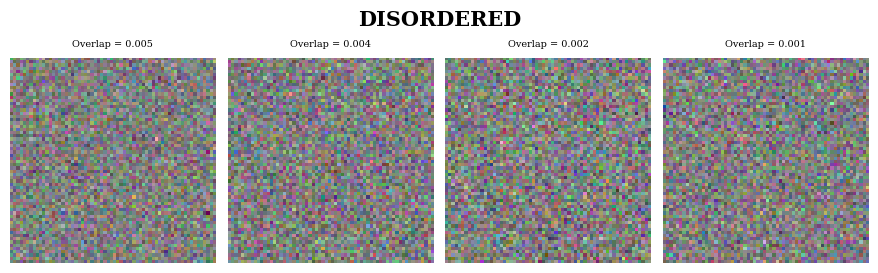

In [14]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=0,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=7,
    max_average_samples=1000,
    top_text = "DISORDERED",
    top_text_fontsize = 15,
)

plt.show()


[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v6/combo_0001_d779788a1ae2/seed_0001_7b9461250fa2/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.002766
[INFO] k=2: |<v_2, uPC_2>|=0.001386
[INFO] k=3: |<v_3, uPC_3>|=0.000685
[INFO] k=4: |<v_4, uPC_4>|=0.003803


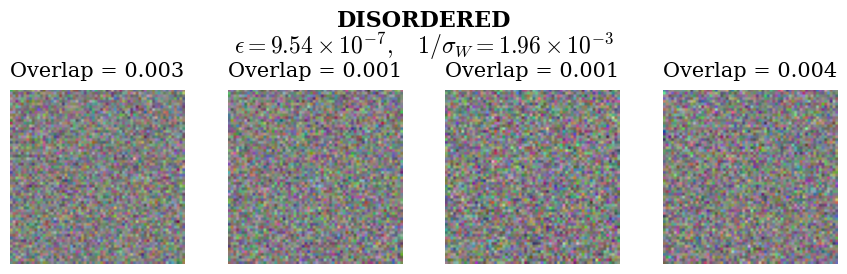

In [36]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=1,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"DISORDERED",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 9.54 \times 10^{-7},\quad 1/\sigma_W = 1.96 \times 10^{-3}$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_diso.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v6/combo_0002_780d8986b203/seed_0001_da173103f94b/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.642359
[INFO] k=2: |<v_2, uPC_2>|=0.001033
[INFO] k=3: |<v_3, uPC_3>|=0.009242
[INFO] k=4: |<v_4, uPC_4>|=0.008008


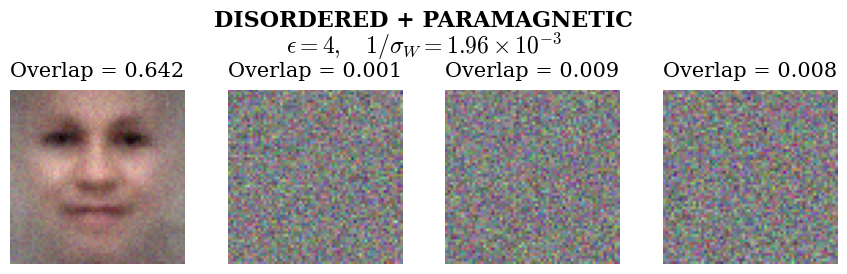

In [43]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=2,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"DISORDERED + PARAMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 4,\quad 1/\sigma_W = 1.96 \times 10^{-3}$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_diso_para.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v6/combo_0003_56866891d42b/seed_0001_1e32993064a1/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.681120
[INFO] k=2: |<v_2, uPC_2>|=0.100307
[INFO] k=3: |<v_3, uPC_3>|=0.228761
[INFO] k=4: |<v_4, uPC_4>|=0.156843


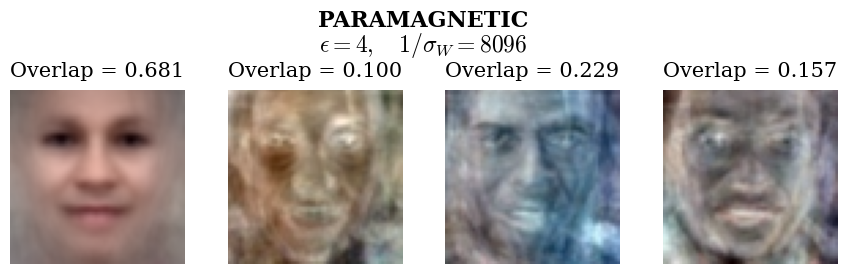

In [39]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=3,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"PARAMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 4,\quad 1/\sigma_W = 8096 $",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_para.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 20000
[INFO] PCA top_m: 4
[INFO] plotted uncentered PCA directions: 4


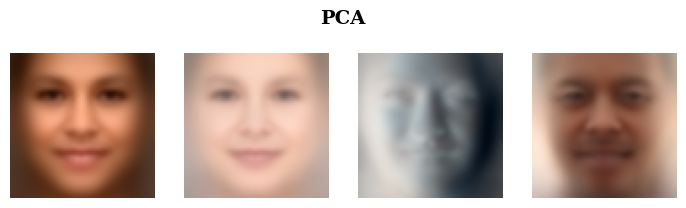

In [34]:
res = plot_uncentered_pca_directions(
    config_path=config_path,
    top_k=4,
    pca_split="all",
    top_text="PCA",
    top_text_fontsize=14,
    wspace=0.2,
    hspace=0.18,
    border_pad=0.01,
)

res["fig"].savefig(
    "img_PCA.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v6/combo_0004_32e86fbafccd/seed_0001_85902ed23ac7/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.036112
[INFO] k=2: |<v_2, uPC_2>|=0.028910
[INFO] k=3: |<v_3, uPC_3>|=0.006728
[INFO] k=4: |<v_4, uPC_4>|=0.035184


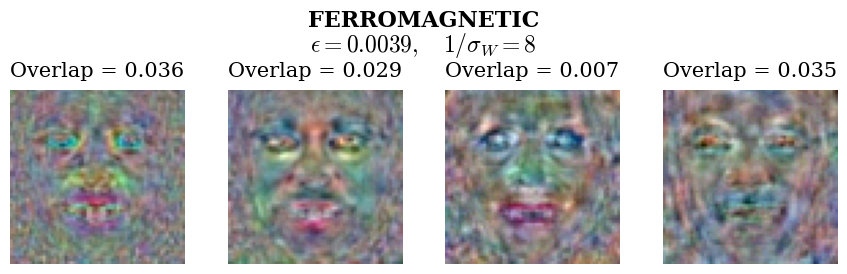

In [42]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=4,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"FERROMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.0039,\quad 1/\sigma_W = 8 $",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_ferro.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

### 3 layers - relu

In [ ]:
results_dir = "../../data/raw_data/exp2_SVD_dnn_BIG_sgd_relu_q_v7"
config_path = "../../experiment_2/DNN_utkface_age_phase_diagram_BIG_q.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
    list_instead_of_grid=True,
)

[DONE] loaded 5 available q combos into memory.
[INFO] mode = list/coupled_grid
[INFO] key meaning: q = index inside coupled_grid
[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...


In [ ]:
res = compute_weight_overlaps_across_seeds(
    "exp2_SVD_dnn_BIG_sgd_relu_q_v7",
    data_root="../../data/raw_data",
    checkpoint_filename="weight_checkpoints.pt",
)

summary = res["summary"]
pairs = res["pairs"]

summary.shape, pairs.shape

((280,), (1680,))

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v7/combo_0000_2387460047fa/seed_0001_748e081aa761/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.002766
[INFO] k=2: |<v_2, uPC_2>|=0.001385
[INFO] k=3: |<v_3, uPC_3>|=0.000686
[INFO] k=4: |<v_4, uPC_4>|=0.003803


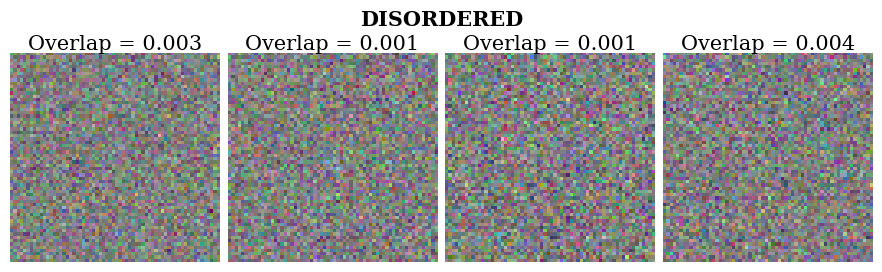

In [28]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=0,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,
    top_text = "DISORDERED",
    top_text_fontsize = 15,
)

## disordered at right

# res_img["fig"].savefig(
#     "img_para_BIG.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=300,
# )

plt.show()


[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v7/combo_0001_c2be16237b3b/seed_0001_930e9a1b61ab/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.002765
[INFO] k=2: |<v_2, uPC_2>|=0.001382
[INFO] k=3: |<v_3, uPC_3>|=0.000685
[INFO] k=4: |<v_4, uPC_4>|=0.003803


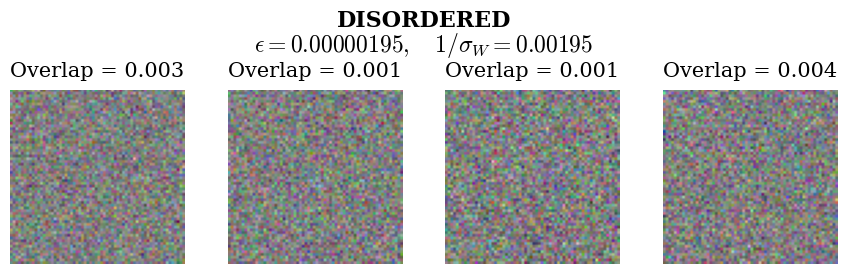

In [29]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=1,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"DISORDERED",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.00000195,\quad 1/\sigma_W = 0.00195$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_diso_BIG.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v7/combo_0002_90a53e09d3ea/seed_0001_a7d97b783f56/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.010060
[INFO] k=2: |<v_2, uPC_2>|=0.034495
[INFO] k=3: |<v_3, uPC_3>|=0.002898
[INFO] k=4: |<v_4, uPC_4>|=0.009663


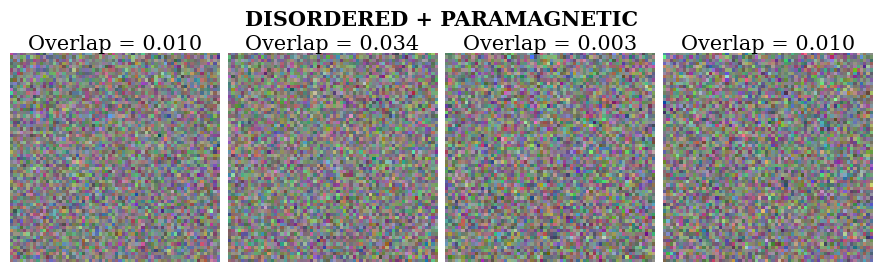

In [33]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=2,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,
    top_text = "DISORDERED + PARAMAGNETIC",
    top_text_fontsize = 15,
)


res_img["fig"].savefig(
    "img_diso_para_BIG.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()


[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v7/combo_0003_5e213d26420a/seed_0002_e67a65d39e37/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.004164
[INFO] k=2: |<v_2, uPC_2>|=0.011327
[INFO] k=3: |<v_3, uPC_3>|=0.004189
[INFO] k=4: |<v_4, uPC_4>|=0.005131


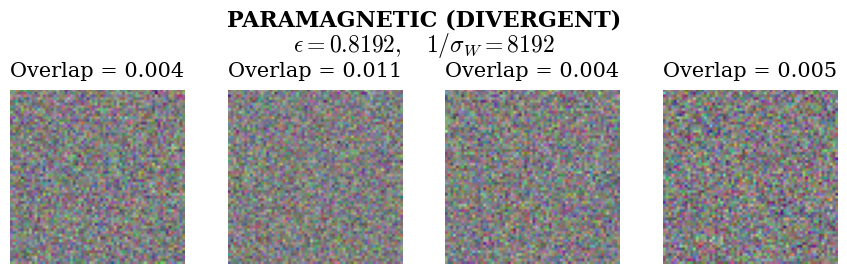

In [19]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=3,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=2,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"PARAMAGNETIC (DIVERGENT)",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.8192,\quad 1/\sigma_W = 8192$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_para_div_BIG.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v7/combo_0004_d28461104973/seed_0001_c991923009f0/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.008337
[INFO] k=2: |<v_2, uPC_2>|=0.039794
[INFO] k=3: |<v_3, uPC_3>|=0.011824
[INFO] k=4: |<v_4, uPC_4>|=0.071587


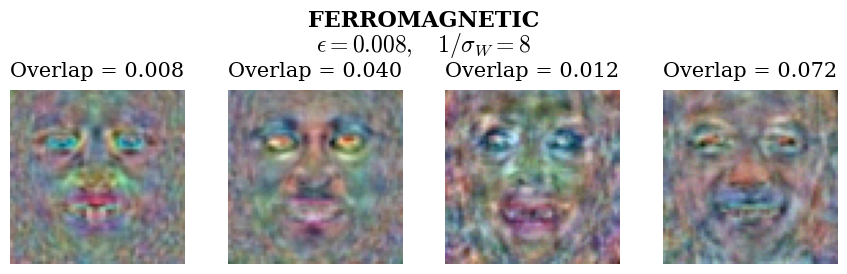

In [31]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=4,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"FERROMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.008,\quad 1/\sigma_W = 8$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_ferro_BIG.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

# Other runs

## Shallow

In [ ]:
results_dir = "../../data/raw_data/exp2_SVD_dnn_SMALL_sgd_relu_q_v10"
config_path = "../../experiment_2/DNN_utkface_age_phase_diagram_q_v2.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
    list_instead_of_grid=True,
)

[DONE] loaded 6 available q combos into memory.
[INFO] mode = list/coupled_grid
[INFO] key meaning: q = index inside coupled_grid
[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...


[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_q_v10/combo_0002_402bceb4bb7b/seed_0001_ccc98cb8f9e1/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.673002
[INFO] k=2: |<v_2, uPC_2>|=0.140807
[INFO] k=3: |<v_3, uPC_3>|=0.023912
[INFO] k=4: |<v_4, uPC_4>|=0.154176


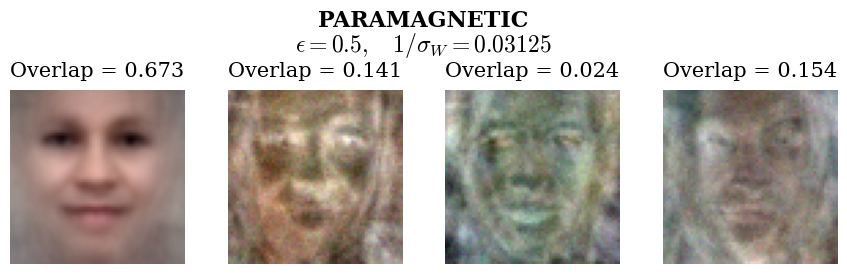

In [33]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=2,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"PARAMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.5,\quad 1/\sigma_W = 0.03125$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

# res_img["fig"].savefig(
#     "img_diso_para_BIG.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=300,
# )

plt.show()

## Deep

In [ ]:
results_dir = "../../data/raw_data/exp2_SVD_dnn_BIG_sgd_relu_q_v10"
config_path = "../../experiment_2/DNN_utkface_age_phase_diagram_BIG_q_v2.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
    list_instead_of_grid=True,
)

[DONE] loaded 9 available q combos into memory.
[INFO] mode = list/coupled_grid
[INFO] key meaning: q = index inside coupled_grid
[INFO] if your grid has only fixed hyperparameters, use store['data'][q] with q=0,1,2,...


[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v10/combo_0003_daa94d288d64/seed_0001_fe71f22509d6/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.241154
[INFO] k=2: |<v_2, uPC_2>|=0.140794
[INFO] k=3: |<v_3, uPC_3>|=0.063842
[INFO] k=4: |<v_4, uPC_4>|=0.049872


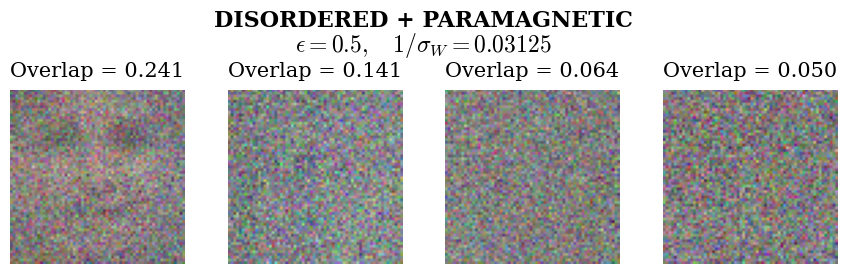

In [22]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=3,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"DISORDERED + PARAMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.5,\quad 1/\sigma_W = 0.03125$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_diso_para_BIG.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

[INFO] weight shape: (256, 12288)
[INFO] requested top_k: 4
[INFO] effective top_k: 4
[INFO] checkpoint: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_q_v10/combo_0004_e0e9358513bd/seed_0001_d92f413205fb/weight_checkpoints.pt
[INFO] dataset root: /mnt/beegfs/2a/mb12724/franc/BBP_in_SGD/dataset/UTKFace
[INFO] PCA split: all
[INFO] PCA n images: 1000
[INFO] PCA top_m: 4
[INFO] k=1: |<v_1, uPC_1>|=0.769286
[INFO] k=2: |<v_2, uPC_2>|=0.499647
[INFO] k=3: |<v_3, uPC_3>|=0.415173
[INFO] k=4: |<v_4, uPC_4>|=0.223806


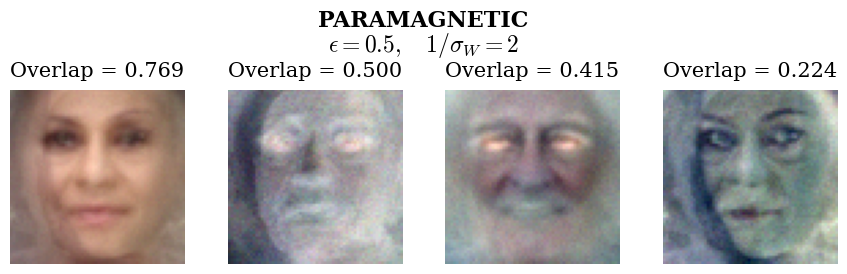

In [23]:
res_img = plot_top_right_vectors_and_dataset_average(
    results_dir=results_dir,
    config_path=config_path,
    list_number=4,
    epoch=300,
    layer_name="layers.0",
    top_k=4,
    seed=1,
    max_cols=4,
    figsize_per_panel=(2.2, 2.6),
    title_fontsize=15,
    max_average_samples=1000,

    top_text=r"PARAMAGNETIC",
    top_text_fontsize=16,

    top_subtitle=r"$\epsilon = 0.5,\quad 1/\sigma_W = 2$",
    top_subtitle_fontsize=17,

    top_text_y=0.99,
    top_subtitle_y=0.91,

    image_title_pad=10,
)

res_img["fig"].savefig(
    "img_para_BIG.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()